## VAE+Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 21.8 MB/s eta 0:00:00


In [2]:
# DNN for regression: inputs from the latent variables space of a VAE, outputs the solar, wind and hydro production over the chosen time-window

import optuna
import torch.optim as optim


class VAE(nn.Module): # VAE inherits from nn.Module, base class for neural network modules in PyTorch.
    def __init__(self, input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, activation):
        super(VAE, self).__init__() # to call init method on the parent class of VAE (nn.Module) so that is has all the same functions

        # encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim1) # hidden_dim: hidden layer neurons of encoder NN
        self.fc2 = nn.Linear(hidden_dim1,hidden_dim2)
        self.fc_mu = nn.Linear(hidden_dim2, latent_dim) # latent_dim : output layer neurons of encoder NN
        self.fc_logvar = nn.Linear(hidden_dim2, latent_dim)

        # decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim3)
        self.fc4 = nn.Linear(hidden_dim3, input_dim)
        self.activation = activation

    def encode(self, x):
        #h1 = self.activation(self.batch1(self.fc1(x)))
        h1 = self.activation((self.fc1(x)))
        h2= self.activation(self.fc2(h1))
        return self.fc_mu(h2), self.fc_logvar(h2)

    def reparameterize(self, mu, logvar): # reparametrization trick to allow backpropagation
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        #h = self.activation(self.batch2(self.fc2(z)))
        h3 = self.activation((self.fc3(z)))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z  # z are the latent representations of the input x


# VAE loss function (separate function, not class method)
def vae_loss(recon_x, x, mu, logvar):
        MSE = F.mse_loss(recon_x, x, reduction='sum')
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return MSE + KLD, MSE, KLD



class Net(nn.Module):
    def __init__(self,Ni,N1,N2,No,activation): # Ni is the dimension of z, N1 the number of hidden neurons of the first layer, N2 the number of hidden neurons of the second layer
        super(Net,self).__init__()

        self.fc1 = nn.Linear(Ni,N1)
        self.batch1 =  nn.BatchNorm1d(N1)
        self.drop1 = nn.Dropout(p=0.1)
        
        self.fc2 = nn.Linear(N1,N2)
        self.batch2 =  nn.BatchNorm1d(N2)
        self.drop2 = nn.Dropout(p=0.1)

        # self.fc3 = nn.Linear(N2, N3)
        # self.batch3 = nn.BatchNorm1d(N3)
        # self.drop3 = nn.Dropout(p=0.1)
        
        self.out = nn.Linear(N2,No)
        self.act = activation


    def forward(self,z): # input from latent variables
            h1 = self.drop1(self.act(self.batch1(self.fc1(z))))
            h2 = self.drop2(self.act(self.batch2(self.fc2(h1))))
        
            #h1= self.act((self.fc1(z)))
            #h2 = self.act((self.fc2(h1)))
         #  h3 = self.drop3(self.act(self.batch3(self.fc3(h2))))
            out = F.relu(self.out(h2))
            return (out)


    def regr_loss(self,y,output,lambda_tik):
        mse = F.mse_loss(output, y,reduction='sum')

        w_norm = 0.0
        for param in self.parameters():
            w_norm += torch.sum(torch.abs(param))

        return mse + lambda_tik*w_norm**2




# here we define the full network architecture for VAE+regression

class VAE_Regression(nn.Module):
    def __init__(self,input_dim, hidden_dim1,hidden_dim2,latent_dim,hidden_dim3,vae_activation,N1,N2,No,activation,lambda_tik):
        super(VAE_Regression,self).__init__()

        self.vae = VAE(input_dim, hidden_dim1,hidden_dim2,latent_dim, hidden_dim3, vae_activation)
        self.regression = Net(latent_dim,N1,N2,No,activation)
        
    def forward(self,x):
        reconstructed_x, mu, logvar, z = self.vae(x) # self.vae(x) is equivalent to calling self.vae.forward(x) thanks to nn.Module
        regr_output = self.regression(mu)
        return (regr_output,reconstructed_x, mu, logvar,z)

    def VAE_loss(self,reconstructed_x, x, mu, logvar): # here VAE_loss/regression_loss are methods of the VAE_Regression class to be accessed later
        return(vae_loss(reconstructed_x, x, mu, logvar))

    def regression_loss(self,y,regr_output,lambda_tik):
        return(self.regression.regr_loss(y,regr_output,lambda_tik))




## Training and test dataset  


In [3]:
df_features = pd.read_csv('lcpb_files/IT_NORD_VAE_input_new.csv') # vae input (input features X)
df_labels = pd.read_csv('lcpb_files/normalized_actuals.csv') # regression training/test
df_labels= df_labels[['date_time','time','detrended_solar','detrended_wind','detrended_hydro']]
df_labels

,date_time,time,detrended_solar,detrended_wind,detrended_hydro
0,2022-01-01 00:00:00+00:00,0.000000,0.0,0.011976,0.099338
1,2022-01-01 01:00:00+00:00,0.000038,0.0,0.131732,0.095132
2,2022-01-01 02:00:00+00:00,0.000076,0.0,0.131728,0.094595
3,2022-01-01 03:00:00+00:00,0.000114,0.0,0.131724,0.097458
4,2022-01-01 04:00:00+00:00,0.000152,0.0,0.131720,0.094236
...,...,...,...,...,...
26371,2024-12-31 22:45:00+00:00,0.999848,0.0,0.265070,0.107815
26372,2024-12-31 23:00:00+00:00,0.999886,0.0,0.037867,0.019329
26373,2024-12-31 23:15:00+00:00,0.999924,0.0,0.037867,0.018974
26374,2024-12-31 23:30:00+00:00,0.999962,0.0,0.033134,0.017910


In [6]:
df_features

,Unnamed: 0,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,day_sin_t0,...,ws_100m_t8,hour_sin_t8,hour_cos_t8,day_sin_t8,day_cos_t8,month_sin_t8,month_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.280164,...,-1.132097,-0.685682,1.408711,0.280448,1.400505,0.702453,1.109234,0.025586,1.291842,2022-01-01 00:00:00
1,1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.280164,...,-0.931334,0.249115,1.890286,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 03:00:00
2,2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.280164,...,-0.778698,1.183912,1.408711,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 06:00:00
3,3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.280164,...,-0.664870,1.571118,0.246088,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 09:00:00
4,4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.280164,...,-0.452988,1.183912,-0.916535,0.552704,1.314595,0.702453,1.109234,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.287572,...,-1.518295,0.249115,-1.398110,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 15:00:00
8316,8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.388240,-0.685682,-0.916535,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8317,8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 18:00:00
8318,8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.287572,...,-1.439442,-1.072887,0.246088,-0.003431,1.429539,-0.019310,1.295919,0.000749,1.292048,2024-12-30 21:00:00


In [4]:
# we use as temporal info the day of the year (1...365)
features = ['day_sin_t0','day_cos_t0',
           'day_sin_t1','day_cos_t1',
           'day_sin_t2','day_cos_t2',
           'day_sin_t3','day_cos_t3',
           'day_sin_t4','day_cos_t4',
           'day_sin_t5','day_cos_t5',
           'day_sin_t6','day_cos_t6',
           'day_sin_t7','day_cos_t7',
           'day_sin_t8','day_cos_t8',
           'month_sin_t0','month_cos_t0',
           'month_sin_t1','month_cos_t1',
           'month_sin_t2','month_cos_t2',
           'month_sin_t3','month_cos_t3',
           'month_sin_t4','month_cos_t4',
           'month_sin_t5','month_cos_t5',
           'month_sin_t6','month_cos_t6',
           'month_sin_t7','month_cos_t7',
           'month_sin_t8','month_cos_t8',
            'Unnamed: 0']

# in alternative one can use the following lines to keep day and month time info
'''
features = ['sin_dayofyear_t0','cos_dayofyear_t0',
            'sin_dayofyear_t1','cos_dayofyear_t1',
            'sin_dayofyear_t2','cos_dayofyear_t2',
            'sin_dayofyear_t3','cos_dayofyear_t3',
            'sin_dayofyear_t4','cos_dayofyear_t4',
            'sin_dayofyear_t5','cos_dayofyear_t5',
            'sin_dayofyear_t6','cos_dayofyear_t6',
            'sin_dayofyear_t7','cos_dayofyear_t7',
            'sin_dayofyear_t8','cos_dayofyear_t8','Unnamed: 0'] '''

df_features = df_features.drop(columns = features)

In [14]:
df_features # methereological data every 3 hours, running over the course of a day  (10 features every 3 hour = 90 features)

,year_t0,2t_t0,solar_t0,tp_t0,ws_10m_t0,ws_100m_t0,hour_sin_t0,hour_cos_t0,sin_dayofyear_t0,cos_dayofyear_t0,...,2t_t8,solar_t8,tp_t8,ws_10m_t8,ws_100m_t8,hour_sin_t8,hour_cos_t8,sin_dayofyear_t8,cos_dayofyear_t8,timestamp
0,-1.224855,-1.266622,-0.785197,-0.540314,-0.169929,0.237315,0.249009,1.890047,0.025562,1.291842,...,-1.279364,-0.785204,-0.539696,-0.982129,-1.132097,-0.685682,1.408711,0.025586,1.291842,2022-01-01 00:00:00
1,-1.224855,-1.324489,-0.785197,-0.540314,-0.167036,0.001132,1.183829,1.408519,0.025562,1.291842,...,-1.305169,-0.785204,-0.539696,-0.791966,-0.931334,0.249115,1.890286,0.050415,1.291222,2022-01-01 03:00:00
2,-1.224855,-1.363120,-0.691746,-0.543042,-0.218606,-0.093139,1.571044,0.246007,0.025562,1.291842,...,-1.369257,-0.785204,-0.539696,-0.709343,-0.778698,1.183912,1.408711,0.050415,1.291222,2022-01-01 06:00:00
3,-1.224855,-1.091436,0.355950,-0.543042,-0.396948,-0.530006,1.183829,-0.916506,0.025562,1.291842,...,-1.427837,-0.704916,-0.537695,-0.616626,-0.664870,1.571118,0.246088,0.050415,1.291222,2022-01-01 09:00:00
4,-1.224855,-0.496955,0.545301,-0.543042,-0.719834,-0.962998,0.249009,-1.398034,0.025562,1.291842,...,-1.170501,0.196247,-0.537695,-0.573833,-0.452988,1.183912,-0.916535,0.050415,1.291222,2022-01-01 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,1.224561,-0.453550,-0.478673,-0.546437,-1.220757,-1.408609,-0.685811,-0.916506,-0.024044,1.291843,...,-0.518011,0.586399,-0.545575,-1.441098,-1.518295,0.249115,-1.398110,0.000749,1.292048,2024-12-30 15:00:00
8316,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-0.567924,-0.485478,-0.545575,-1.249467,-1.388240,-0.685682,-0.916535,0.000749,1.292048,2024-12-30 18:00:00
8317,1.224561,-1.110274,-0.785197,-0.545773,-1.125086,-1.549938,-1.073026,0.246007,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 18:00:00
8318,1.224561,-1.322641,-0.785197,-0.545773,-1.180936,-1.527834,-0.685811,1.408519,-0.024044,1.291843,...,-1.247314,-0.785204,-0.544950,-1.301211,-1.439442,-1.072887,0.246088,0.000749,1.292048,2024-12-30 21:00:00


In [5]:
#Here we define the labels: (mean_solar, mean_wind, mean_hydro production) over the time window of 3 hours

df_labels['date_time'] = pd.to_datetime(df_labels['date_time']).dt.tz_localize(None)
df_features['timestamp'] = pd.to_datetime(df_features['timestamp']).dt.tz_localize(None)

df_labels.set_index('date_time', inplace=True)

y_list = []

# for every row of df_features
for ts in df_features['timestamp']:
    # time window: from t to t + 24h , we will input meteo data of a 24h window and predict energy prodcution of the last 3h of that window
    window_start = ts + pd.Timedelta(hours=21)
    window_end = ts + pd.Timedelta(hours=24)

    # select production rows in this time window
    window_data = df_labels.loc[window_start:window_end]

    # determine the average in this window
    if not window_data.empty:
        #mean_vals = window_data[['detrended_solar', 'detrended_wind', 'detrended_hydro']].mean().values
        mean_vals = window_data[['detrended_solar', 'detrended_wind']].mean().values
    else:
        mean_vals = [float('nan'), float('nan'), float('nan')]  # se non ci sono dati in quella finestra

    y_list.append(mean_vals)

#y_df = pd.DataFrame(y_list, columns=['mean_solar', 'mean_wind', 'mean_hydro'])
y_df = pd.DataFrame(y_list, columns=['mean_solar', 'mean_wind'])



In [6]:
from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#y_df = pd.DataFrame(scaler.fit_transform(y_df), columns=y_df.columns, index=y_df.index)
#df_training = pd.concat([df_features, y_df], axis=1) # full training dataset (both X,Y)
y_df

,mean_solar,mean_wind
0,0.000000,0.125658
1,0.000000,0.146587
2,0.000000,0.174989
3,0.027699,0.200397
4,0.106519,0.162994
...,...,...
8315,0.102457,0.191520
8316,0.001920,0.284004
8317,0.001920,0.284004
8318,0.000000,0.295655


In [6]:
from sklearn.model_selection import train_test_split


#X_array = df_features.drop(columns=['timestamp']).iloc[:,0:20].values # 6h windows
X_array = df_features.drop(columns=['timestamp']).values # 24h windows
Y_array = y_df.values if isinstance(y_df, pd.DataFrame) else y_df

n_samples = len(X_array)
split_idx = int(n_samples * 0.8)


X_train = X_array[:split_idx]
X_test = X_array[split_idx:] # we do not randomly split into training and test set to avoid replicating data across both (it's a time-series with sliding windows)

Y_train = Y_array[:split_idx]
Y_test = Y_array[split_idx:]

# keep track of the original indices and timestamps
idx_train = df_features.index[:split_idx] # to retrieve date/time at test time (for predictions)
idx_test = df_features.index[split_idx:]

test_timestamps = df_features.loc[idx_test, 'timestamp'].reset_index(drop=True)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)

# create a DataLoader for batching (training time)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

# create a DataLoader for batching (training time)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
X_train_tensor.shape

torch.Size([6656, 90])

# Prove generali (useless)

In [ ]:
def train(model, train_loader, optimizer, device):
    model.train()

    total_loss = 0.0
    total_vae_loss = 0.0
    total_regr_loss = 0.0
    beta=1/2

    for data, target in train_loader:

        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        # forward pass
        regr_output,recon_x, mu, logvar,z = model(data)

        # compute losses
        vae_loss_val, _, _ = model.VAE_loss(recon_x, data, mu, logvar)
        regr_loss_val = model.regression_loss(target, regr_output,lambda_tik)

        loss = (1-beta)*regr_loss_val + beta*vae_loss_val  # small beta to focus on minizmizing regression loss (or just use regr_loss)

        loss.backward()
        optimizer.step() # updates weights with gradients/parameters found


        total_loss += loss.item()
        total_vae_loss += vae_loss_val.item()
        total_regr_loss += regr_loss_val.item()

         # average losses over all batches
    avg_loss = total_loss / len(train_loader)
    avg_vae_loss = total_vae_loss / len(train_loader)
    avg_regr_loss = total_regr_loss / len(train_loader)

    return avg_loss, avg_vae_loss, avg_regr_loss


input_dim = X_train_tensor.shape[1] # number of input features
latent_dim = 16 #4
hidden_dim1 = 32 #16
hidden_dim2 = 32 #16
N1 = 16
N2 = 16
No = Y_train_tensor.shape[1]  # 3 outputs (solar, wind, hydro)
activation_fn = nn.LeakyReLU ()
lambda_tik = 3.42*10**-6

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE_Regression(input_dim, hidden_dim1,hidden_dim2,latent_dim,hidden_dim3, activation_fn, N1, N2,No,activation_fn,lambda_tik).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.00659)


loss = train(model,train_loader, optimizer, device)

model.eval()

test_predictions=[]
with torch.no_grad(): # disable gradient calculation for inference
    for i in range(10000):
      regr_output, reconstructed_x, mu, logvar, z = model(X_test_tensor.to(device))
      test_predictions.append(regr_output)  # shape: [100, test_size, 3]

test_predictions_tensor = torch.stack(test_predictions)

# compute mean across the 100 runs: shape becomes [test_size, 3]
mean_test_predictions = test_predictions_tensor.mean(dim=0).cpu()


z = z.cpu().numpy()
recon_x_test = reconstructed_x.cpu().numpy()

print(mean_test_predictions)
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),0],color='red',label=' solar prediction')
plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),0],color='blue',label='test data')
plt.legend()
plt.show()

<ipython-input-12-62113f46430f>:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),0]-Y_test[:int(len(Y_test)/10),0],color='red',label=' solar prediction error')


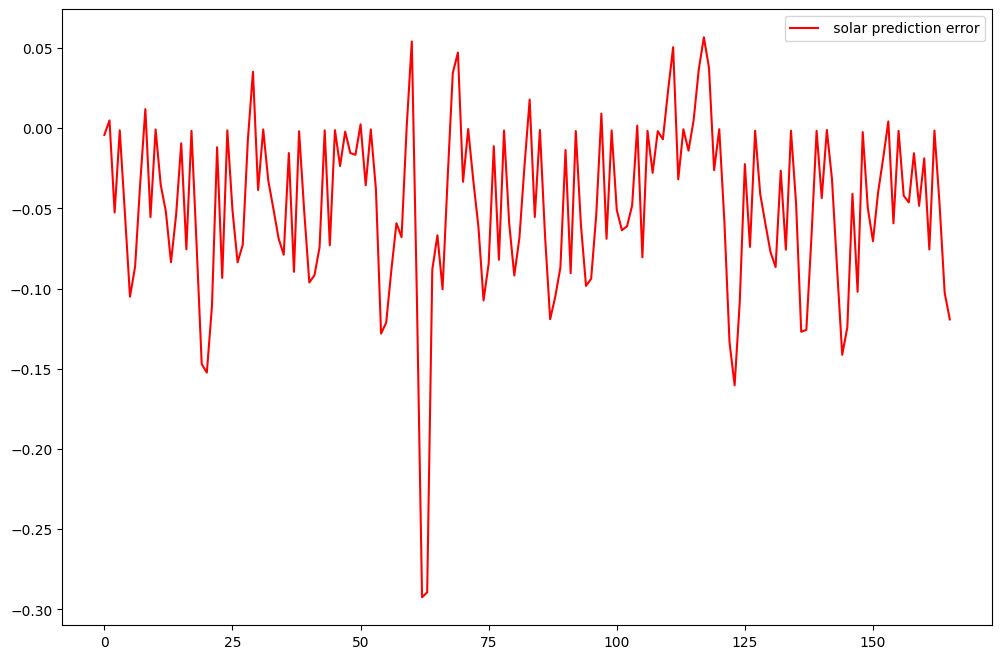

In [12]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),0]-Y_test[:int(len(Y_test)/10),0],color='red',label=' solar prediction error')
#plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),0],color='blue',label='test data')
plt.legend()
plt.show()

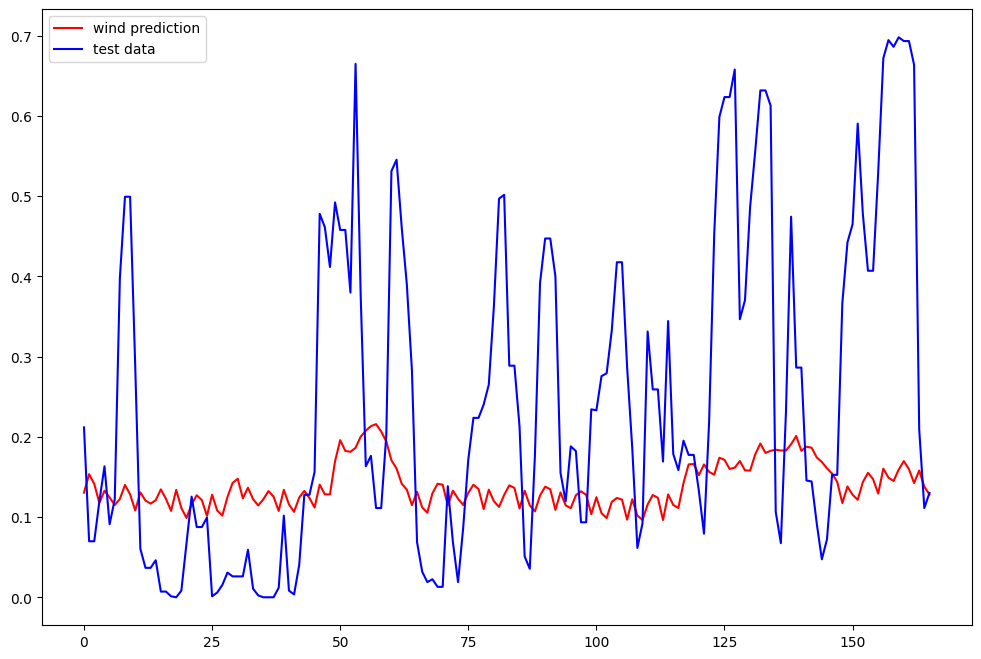

In [13]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),1],color='red',label='wind prediction')
plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),1],color='blue',label='test data')
plt.legend()
plt.show()

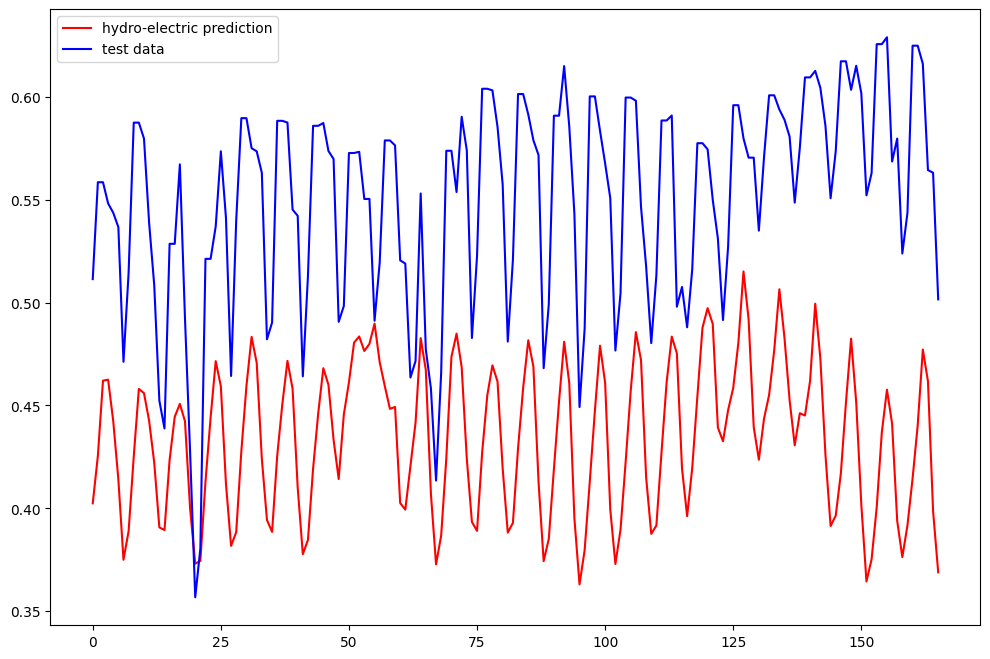

In [14]:
plt.figure(figsize=(12, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/10)),mean_test_predictions[:int(len(mean_test_predictions)/10),2],color='red',label='hydro-electric prediction')
plt.plot(np.arange(int(len(Y_test)/10)),Y_test[:int(len(Y_test)/10),2],color='blue',label='test data')
plt.legend()
plt.show()

## GRID SEARCH WITH K-FOLD CROSS VALIDATION

In [8]:
import json
import optuna
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit

# here we perform a grid search to look for the best hyperparameters: we choose to use 4 folds. We fix as objective to minimize the average validation error over the folds
# To compute each loss estimation before udating the weights, we perform 100 evaluations of the predicted outputs and consider their average as prediction

def get_activation(name):
    return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()
    }[name]

# load best VAE hyperparamters config previously found
#with open("/home/weights_VAE/vae_best_model_n100.json", "r") as f:
#    vae_best_params = json.load(f)
#print(vae_best_params )
#vae_weights_path = "/home/weights_VAE/vae_best_model_weights_n100.pt"

def objective(trial):
   
    hidden_dim1 = trial.suggest_categorical("hidden_dim1", [128,256]) # previous range 64-256
    hidden_dim2 = trial.suggest_categorical("hidden_dim2", [64,128]) #  previous range 64-256
    latent_dim = trial.suggest_categorical("latent_dim", [12,14,16,18,20]) # previous range 6-20
    hidden_dim3 = trial.suggest_categorical("hidden_dim3",[256] )  # previous range 64-256

    N1 = trial.suggest_categorical("N1", [64,128,256]) # previous range 16-256
    N2 = trial.suggest_categorical("N2", [64,128,256])

    lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6,1e-4, log=True)
    lr = trial.suggest_float("lr",1e-5,1e-4, log=True)
    act_name = trial.suggest_categorical("activation", ["relu"]) # previous searches also with sigmoid and leaky relu 
    activation_fn = get_activation(act_name)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 110
    batch_size = 16
    beta = 1./800
    num_folds = 2
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        #vae_act = get_activation("relu")

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            # hidden_dim1=vae_best_params["H_DIM"],
            # latent_dim=vae_best_params["Z_DIM"],
            # hidden_dim2=vae_best_params["H_DIM"],
            hidden_dim1=hidden_dim1,
            hidden_dim2=hidden_dim2,
            latent_dim=latent_dim,
            hidden_dim3=hidden_dim3,
            vae_activation= activation_fn,
            N1=N1,
            N2=N2,
            No=Y_train_fold.shape[1],
            activation=activation_fn,
            lambda_tik=lambda_tik
        ).to(device)

        # load pretrained VAE weights

        #     key_mapping = {
        # 'img_2hid.weight': 'vae.fc1.weight',
        # 'img_2hid.bias': 'vae.fc1.bias',
        # 'hid_2mu.weight': 'vae.fc_mu.weight',
        # 'hid_2mu.bias': 'vae.fc_mu.bias',
        # 'hid_2sigma.weight': 'vae.fc_logvar.weight',
        # 'hid_2sigma.bias': 'vae.fc_logvar.bias',
        # 'z_2hid.weight': 'vae.fc2.weight',
        # 'z_2hid.bias': 'vae.fc2.bias',
        # 'hid_2img.weight': 'vae.fc3.weight',
        # 'hid_2img.bias': 'vae.fc3.bias'
        # }

        #     # we load pretrained weights and apply mapping to match dictionary keys

        #     raw_pretrained_dict = torch.load(vae_weights_path, map_location=device)
        #     model_dict = model.state_dict()

        #     mapped_dict = {}
        #     for old_k, new_k in key_mapping.items():
        #         if new_k in model_dict and old_k in raw_pretrained_dict:
        #             mapped_dict[new_k] = raw_pretrained_dict[old_k]

        # update the weights of the pre trained vae model
        #     model_dict.update(mapped_dict)
        #     model.load_state_dict(model_dict)

        #    for name, param in model.named_parameters():
        #        if name in mapped_dict:
        #             param.requires_grad = False  # freeze previosuly trained VAE weights!

        #print("Model state dict keys:")
        #for k in model_dict.keys():
            #print(k)
        #print("Pre-trained dict: ", mapped_dict,"\n")

        #print("\n Ensure VAE weights are correctly loaded:")

        #for name in mapped_dict:
        #   current = model.state_dict()[name]
        #   loaded = mapped_dict[name]

        #if torch.allclose(current, loaded, atol=1e-6):
        #print(f" - {name}: OK")
        #else:
        #print(f" - {name}: Divergence in loaded weights!!")

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,       ## wait 8 epochs of no improvement after which shrink LR by half
            patience=10)      

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                # n=1
                # train_out=[]
                # train_recon_x=[]
                # for i in range(n):
                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                #train_out.append(regr_output)
                #train_recon_x.append(recon_x)

                #train_out_tensor = torch.stack(train_out)
                #train_recon_x_tensor = torch.stack(train_recon_x)

                #mean_regr_output = train_out_tensor.mean(dim=0)
                #mean_recon_x = train_recon_x_tensor.mean(dim=0)

                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1-beta)*regr_loss + beta * vae_loss  # this trick normalizes each loss to 1.0, but keeps its gradient direction (only the numerator contributes to the backward pass)
                #loss = (1-beta)*regr_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
               
                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            # validation

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch=0.
            val_regr_loss_epoch=0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                    #val_out=[]
                    #val_recon_x=[]
                    #for i in range(n):
                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    #val_out.append(regr_output)
                    #val_recon_x.append(recon_x)

                    #val_out_tensor = torch.stack(val_out)
                    #val_recon_x_tensor = torch.stack(val_recon_x)

                    #mean_regr_output = val_out_tensor.mean(dim=0)
                    #mean_recon_x = val_recon_x_tensor.mean(dim=0)

                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1-beta)*regr_loss + beta * vae_loss
                    #val_loss= (1-beta)*regr_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            epoch_train_losses[epoch] += (train_loss_epoch)/num_folds
            epoch_val_losses[epoch] += (val_loss_epoch)/num_folds
            epoch_val_vae_losses[epoch] += (val_vae_loss_epoch)/num_folds
            epoch_val_regr_losses[epoch] += (val_regr_loss_epoch)/num_folds

            print(f"Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    model_path = f"weights_VAE_Regression/New_2/model_trial_{trial.number}.pt"
    torch.save(model.state_dict(), model_path)
    trial.set_user_attr("model_path", model_path) # to later have the path of the best model

    return np.mean(epoch_val_regr_losses[-15:])  # loss Optuna will minimize this with the hyper paramters search


In [14]:
#print(vae_best_params)
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#pretrained_dict = torch.load(vae_weights_path, map_location=device)
#print("Loaded keys from pretrained_dict:")
#for k in pretrained_dict.keys():
#    print(k)

Loaded keys from pretrained_dict:
img_2hid.weight
img_2hid.bias
hid_2mu.weight
hid_2mu.bias
hid_2sigma.weight
hid_2sigma.bias
z_2hid.weight
z_2hid.bias
hid_2img.weight
hid_2img.bias


In [10]:
#study = optuna.create_study(directions=["minimize","minimize"],pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10))
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=45))
from tqdm import tqdm
n_trials = 90
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-05-31 13:01:56,455] A new study created in memory with name: no-name-cf17780d-e1e7-4ad9-beb8-a780cdd7164d
Optuna Trials:   0%|                                                                          | 0/90 [00:00<?, ?trial/s]

Epoch [1/110] - Total val loss: 133.8330, VAE: 680.4694, Regr: 133.1488
Epoch [2/110] - Total val loss: 120.3017, VAE: 675.2885, Regr: 119.6071
Epoch [3/110] - Total val loss: 107.8973, VAE: 675.4473, Regr: 107.1869
Epoch [4/110] - Total val loss: 96.6780, VAE: 679.5582, Regr: 95.9485
Epoch [5/110] - Total val loss: 86.7492, VAE: 683.5464, Regr: 86.0022
Epoch [6/110] - Total val loss: 77.8069, VAE: 689.5915, Regr: 77.0413
Epoch [7/110] - Total val loss: 69.7886, VAE: 696.6071, Regr: 69.0041
Epoch [8/110] - Total val loss: 62.7359, VAE: 704.2128, Regr: 61.9330
Epoch [9/110] - Total val loss: 56.4916, VAE: 709.3362, Regr: 55.6745
Epoch [10/110] - Total val loss: 51.0390, VAE: 714.8977, Regr: 50.2081
Epoch [11/110] - Total val loss: 46.2391, VAE: 718.8984, Regr: 45.3972
Epoch [12/110] - Total val loss: 41.9613, VAE: 721.3610, Regr: 41.1110
Epoch [13/110] - Total val loss: 38.2372, VAE: 725.0845, Regr: 37.3776
Epoch [14/110] - Total val loss: 34.9181, VAE: 724.0273, Regr: 34.0557
Epoch [15

[I 2025-05-31 13:09:49,917] Trial 0 finished with value: 5.447134469681793 and parameters: {'hidden_dim1': 128, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 256, 'N1': 256, 'N2': 256, 'lambda_tik': 2.982030723197395e-05, 'lr': 1.6224813762064538e-05, 'activation': 'relu'}. Best is trial 0 with value: 5.447134469681793.
Optuna Trials:   1%|▋                                                             | 1/90 [07:53<11:42:17, 473.45s/trial]

Epoch [110/110] - Total val loss: 6.2677, VAE: 1009.7631, Regr: 5.0117
Epoch [1/110] - Total val loss: 45.3170, VAE: 686.1439, Regr: 44.5149
Epoch [2/110] - Total val loss: 34.7128, VAE: 718.1281, Regr: 33.8575
Epoch [3/110] - Total val loss: 26.4289, VAE: 738.5522, Regr: 25.5377
Epoch [4/110] - Total val loss: 20.1083, VAE: 749.8609, Regr: 19.1950
Epoch [5/110] - Total val loss: 15.5952, VAE: 748.4554, Regr: 14.6780
Epoch [6/110] - Total val loss: 12.2835, VAE: 756.3279, Regr: 11.3523
Epoch [7/110] - Total val loss: 9.8887, VAE: 758.9453, Regr: 8.9512
Epoch [8/110] - Total val loss: 8.0661, VAE: 759.1929, Regr: 7.1260
Epoch [9/110] - Total val loss: 6.8295, VAE: 756.9528, Regr: 5.8907
Epoch [10/110] - Total val loss: 5.9007, VAE: 752.7005, Regr: 4.9660
Epoch [11/110] - Total val loss: 5.2286, VAE: 743.6341, Regr: 4.3045
Epoch [12/110] - Total val loss: 4.7282, VAE: 732.6375, Regr: 3.8172
Epoch [13/110] - Total val loss: 4.3781, VAE: 721.1239, Regr: 3.4811
Epoch [14/110] - Total val lo

[I 2025-05-31 13:16:53,773] Trial 1 finished with value: 0.927561286877957 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 5.04506263165086e-05, 'lr': 7.718651039106131e-05, 'activation': 'relu'}. Best is trial 1 with value: 0.927561286877957.
Optuna Trials:   2%|█▍                                                            | 2/90 [14:57<10:51:36, 444.28s/trial]

...

Epoch [110/110] - Total val loss: 1.8597, VAE: 517.5774, Regr: 1.2143
Epoch [1/110] - Total val loss: 10.0525, VAE: 696.8169, Regr: 9.1930
Epoch [2/110] - Total val loss: 9.0036, VAE: 755.3063, Regr: 8.0695
Epoch [3/110] - Total val loss: 7.7156, VAE: 758.2833, Regr: 6.7762
Epoch [4/110] - Total val loss: 6.7334, VAE: 765.1619, Regr: 5.7842
Epoch [5/110] - Total val loss: 5.9018, VAE: 768.0751, Regr: 4.9479
Epoch [6/110] - Total val loss: 5.2583, VAE: 765.0128, Regr: 4.3074
Epoch [7/110] - Total val loss: 4.7030, VAE: 760.3306, Regr: 3.7573
Epoch [8/110] - Total val loss: 4.3062, VAE: 764.2971, Regr: 3.3550
Epoch [9/110] - Total val loss: 3.9697, VAE: 761.4660, Regr: 3.0217
Epoch [10/110] - Total val loss: 3.6615, VAE: 747.1026, Regr: 2.7311
Epoch [11/110] - Total val loss: 3.3938, VAE: 733.5790, Regr: 2.4800
Epoch [12/110] - Total val loss: 3.2143, VAE: 713.4094, Regr: 2.3254
Epoch [13/110] - Total val loss: 3.0175, VAE: 689.8467, Regr: 2.1579
Epoch [14/110] - Total val loss: 2.8690, 

[I 2025-06-01 10:22:08,109] Trial 88 finished with value: 2.2059818094422066 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 12, 'hidden_dim3': 256, 'N1': 256, 'N2': 64, 'lambda_tik': 1.0568069872994483e-05, 'lr': 7.470071661604657e-05, 'activation': 'relu'}. Best is trial 1 with value: 0.927561286877957.
Optuna Trials:  99%|███████████████████████████████████████████████████████████▎| 89/90 [21:20:11<55:43, 3343.30s/trial]

Epoch [110/110] - Total val loss: 2.6262, VAE: 524.8904, Regr: 1.9726
Epoch [1/110] - Total val loss: 27.4004, VAE: 685.5373, Regr: 26.5767
Epoch [2/110] - Total val loss: 19.6287, VAE: 704.3696, Regr: 18.7717
Epoch [3/110] - Total val loss: 14.8498, VAE: 721.1146, Regr: 13.9658
Epoch [4/110] - Total val loss: 11.7353, VAE: 729.4588, Regr: 10.8370
Epoch [5/110] - Total val loss: 9.6223, VAE: 734.2274, Regr: 8.7154
Epoch [6/110] - Total val loss: 8.0651, VAE: 737.3029, Regr: 7.1524
Epoch [7/110] - Total val loss: 6.9084, VAE: 737.9175, Regr: 5.9935
Epoch [8/110] - Total val loss: 6.1398, VAE: 741.8353, Regr: 5.2190
Epoch [9/110] - Total val loss: 5.5244, VAE: 742.7250, Regr: 4.6018
Epoch [10/110] - Total val loss: 5.0206, VAE: 753.7214, Regr: 4.0836
Epoch [11/110] - Total val loss: 4.6874, VAE: 760.7493, Regr: 3.7412
Epoch [12/110] - Total val loss: 4.3910, VAE: 759.2345, Regr: 3.4463
Epoch [13/110] - Total val loss: 4.1496, VAE: 763.0132, Regr: 3.1999
Epoch [14/110] - Total val loss: 3

[I 2025-06-01 10:29:46,260] Trial 89 finished with value: 2.0121822160889775 and parameters: {'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 18, 'hidden_dim3': 256, 'N1': 256, 'N2': 256, 'lambda_tik': 7.116144154834405e-06, 'lr': 6.682763658359221e-05, 'activation': 'relu'}. Best is trial 1 with value: 0.927561286877957.
Optuna Trials: 100%|█████████████████████████████████████████████████████████████| 90/90 [21:27:49<00:00, 858.55s/trial]

Epoch [110/110] - Total val loss: 2.6953, VAE: 535.4253, Regr: 2.0285


In [27]:
best_trial_1= study.best_trial
best_params_1 = best_trial.params
print(best_params_1)

{'hidden_dim1': 128, 'hidden_dim2': 128, 'latent_dim': 14, 'hidden_dim3': 256, 'N1': 32, 'N2': 128, 'lambda_tik': 0.0001425151107702199, 'lr': 0.00017206350238630318, 'activation': 'relu'}


In [10]:
best_trial_2= study.best_trial
best_params_2 = best_trial.params
print(best_params_2)

{'hidden_dim1': 128, 'hidden_dim2': 64, 'latent_dim': 20, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 3.096176320371018e-05, 'lr': 0.0004154465741986691, 'activation': 'relu'}


In [11]:
best_trial = study.best_trial
best_params = best_trial.params
print(best_params)

{'hidden_dim1': 256, 'hidden_dim2': 128, 'latent_dim': 16, 'hidden_dim3': 256, 'N1': 64, 'N2': 256, 'lambda_tik': 5.04506263165086e-05, 'lr': 7.718651039106131e-05, 'activation': 'relu'}


We run another grid search with restricted intervals for the different hyperparamters.

In [12]:
import json

# choose the model with best trade-off between regression and valid loss
best_trial= study.best_trial
#pareto_trials = study.best_trials
##
#losses = np.array([t.values for t in pareto_trials])  # shape: (n_trials, 2)
##
#vae_losses = losses[:, 0]
#regr_losses = losses[:, 1]
##
### normalize losses to [0, 1] to compare
##
#eps = 1e-8
#vae_range = vae_losses.max() - vae_losses.min()
#regr_range = regr_losses.max() - regr_losses.min()
#
#vae_norm = (vae_losses - vae_losses.min()) / (vae_range + eps)
#regr_norm = (regr_losses - regr_losses.min()) / (regr_range + eps)
#
### define a distance metric from the origin (ideal point with 0 loss) and choose trial with lower distance
#distances = np.sqrt(vae_norm**2 + regr_norm**2)
#best_idx = np.argmin(distances)
##best_idx=0
#best_trial = pareto_trials[best_idx]



# get its best hyperparameters
best_activation = get_activation(best_params["activation"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


best_model = VAE_Regression(
            input_dim= X_train.shape[1],
           # hidden_dim1=vae_best_params["H_DIM"],
           # latent_dim=vae_best_params["Z_DIM"],
           # hidden_dim2=vae_best_params["H_DIM"],
            hidden_dim1=best_params['hidden_dim1'],
            hidden_dim2=best_params['hidden_dim2'],
            latent_dim=best_params['latent_dim'],
            hidden_dim3=best_params['hidden_dim3'],
            vae_activation= best_activation,
            N1=best_params['N1'],
            N2=best_params['N2'],
            No=Y_train.shape[1],
            activation= best_activation,
            lambda_tik=best_params['lambda_tik']
        ).to(device)

#best_model = VAE_Regression(
#    input_dim=X_train_tensor.shape[1],
#    hidden_dim1=vae_best_params["H_DIM"],
#    latent_dim=vae_best_params["Z_DIM"],
#    hidden_dim2=vae_best_params["H_DIM"],
#    vae_activation=best_activation,
#    N1=best_params["N1"],
#    N2=best_params["N2"],
#    No=Y_train_tensor.shape[1],
#    activation=best_activation,
#    lambda_tik=best_params["lambda_tik"]
#).to(device)

# load the weights of the best trial
best_model.load_state_dict(torch.load(best_trial.user_attrs["model_path"]))

trial=0
trial += 1
# saves current hyperparamters and weights (which you just loaded) into a new file

with open("best_Regr_models/best_model_1_June_hyperparams.json", "w") as f:
    json.dump(best_params, f)

torch.save(best_model.state_dict(), f"best_Regr_models/best_model_1_June_{trial}.pt")


/tmp/ipykernel_300/2359636402.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_trial.user_attrs["model_path"]))


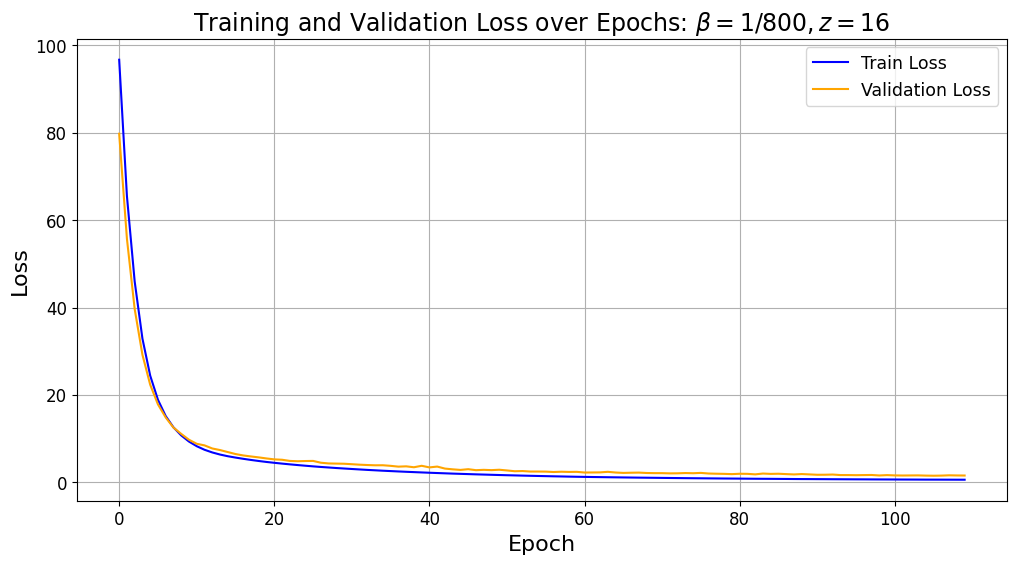

<Figure size 640x480 with 0 Axes>

In [13]:
# plot training and validation losses over epochs
#best_model.load_state_dict(torch.load("lcpb_files/best_model_overall.pt"))

train_loss_curve = np.array(best_trial.user_attrs["mean_train_loss_curve"])
val_loss_curve = np.array(best_trial.user_attrs["mean_val_loss_curve"])
val_vae_loss_curve = np.array(best_trial.user_attrs["mean_val_vae_loss_curve"])
val_regr_loss_curve = np.array(best_trial.user_attrs["mean_val_regr_loss_curve"])

epochs = np.arange(len(train_loss_curve))

plt.figure(figsize=(12, 6))


plt.rcParams.update({
    'axes.titlesize': 17,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12.5
})

plt.plot(epochs, train_loss_curve, label='Train Loss', color='blue')
plt.plot(epochs, val_loss_curve, label='Validation Loss', color='orange')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(r"Training and Validation Loss over Epochs: $\beta=1/800,z=16$")
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("plots/best_model_1_June_loss_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')

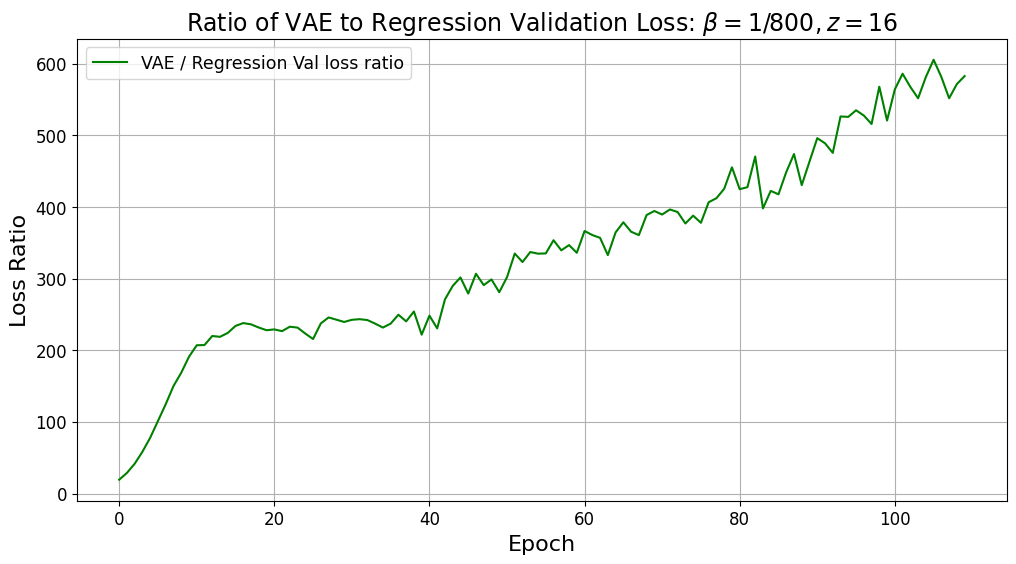

<Figure size 640x480 with 0 Axes>

In [14]:
loss_ratio = val_vae_loss_curve / (val_regr_loss_curve + 1e-9)  # avoid division by zero

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss_ratio, label='VAE / Regression Val loss ratio', color='green')
plt.xlabel("Epoch")
plt.ylabel("Loss Ratio")
plt.title(r"Ratio of VAE to Regression Validation Loss: $\beta=1/800,z=16$")
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("plots/best_model_1_June_ratio_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')

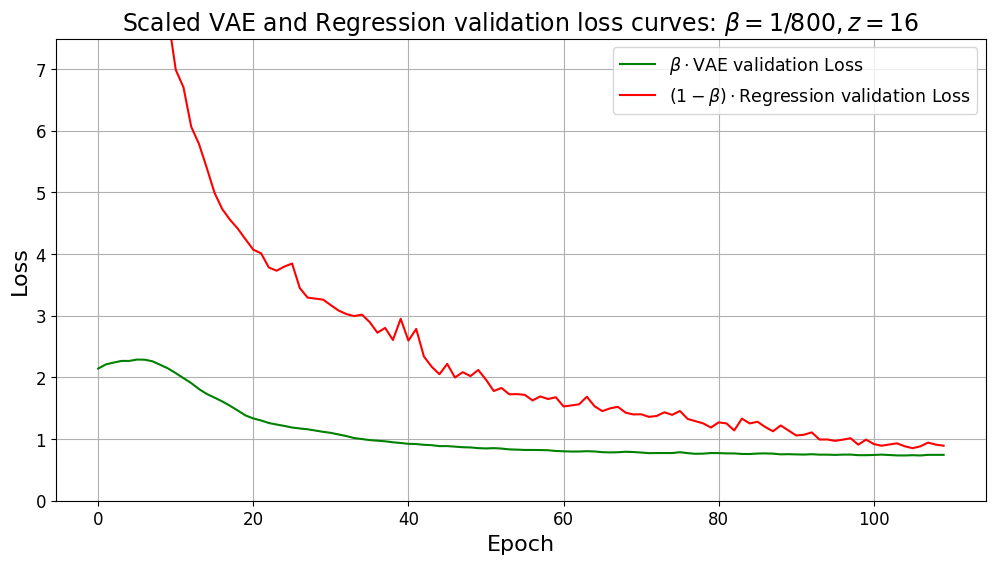

<Figure size 640x480 with 0 Axes>

In [42]:
fig,ax= plt.subplots(figsize=(12,6))
beta = 1./700
ax.plot(epochs, beta*val_vae_loss_curve, label=r'$\beta \cdot$VAE validation Loss', color='green')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(r"Scaled VAE and Regression validation loss curves: $\beta=1/800,z=16$")

ax.plot(epochs, (1-beta)*val_regr_loss_curve, label=r'$(1-\beta)\cdot$Regression validation Loss', color='red')
plt.ylim(0,5*np.min(val_loss_curve))
ax.grid(True)
ax.legend()
plt.show()
plt.savefig("plots/best_model_1_June_vae_regr_losses_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')

In [ ]:
# NO!


#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#recon_x_vec = []
#test_predictions=[]
#
#with torch.no_grad(): # disable gradient calculation for inference
#    for i in range(4000):
#      regr_output, reconstructed_x, mu, logvar, z = model(X_test_tensor.to(device))
#      test_predictions.append(regr_output)  # shape: [100, test_size, 3]
#      recon_x_vec.append(reconstructed_x)
#
## convert to tensor
#test_predictions_tensor = torch.stack(test_predictions)
#recon_x_tensor= torch.stack(recon_x_vec)
#
## compute mean across the 100 runs: shape becomes [test_size, 3]
#mean_test_predictions = test_predictions_tensor.mean(dim=0)
## mean over passes
#mean_test_predictions = test_predictions_tensor.mean(dim=0).cpu().numpy()
#mean_recon_x_test = recon_x_tensor.mean(dim=0).cpu().numpy()
#
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),0],color='red',label='Solar production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),0],color='orange',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized solar energy production")
plt.title(r"Prediction of solar energy production: Test set ($\beta=0$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/best_model_beta_1/1000_z_20.png", dpi=300, bbox_inches='tight')
plt.show()


[[0.07687367 0.32187223]
 [0.         0.2931615 ]
 [0.         0.22086751]
 ...
 [0.         0.2267462 ]
 [0.         0.09485417]
 [0.         0.06384117]]


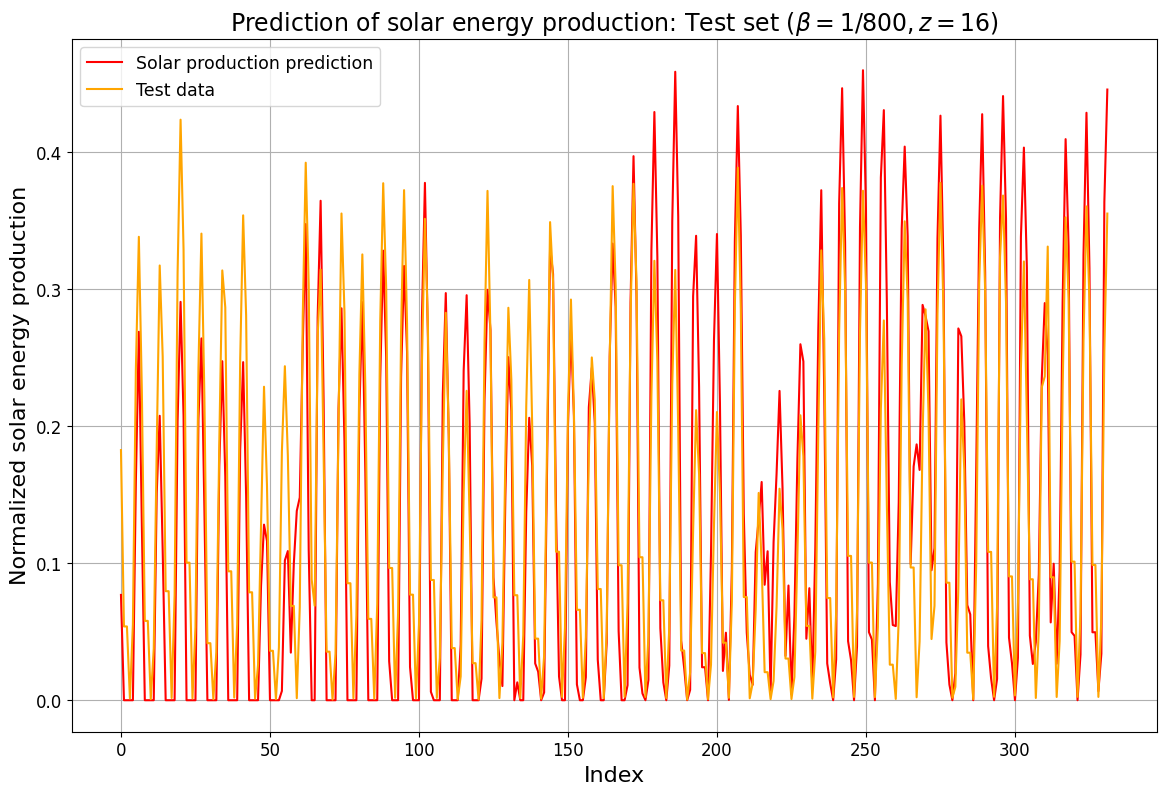

In [31]:
#best_params = best_trial.params
#activation_fn = get_activation(best_params["activation"])

#best_model = VAE_Regression(
#    input_dim= X_test_tensor.shape[1],
#    hidden_dim1=best_params["hidden_dim1"],
#    latent_dim=best_params["latent_dim"],
#    hidden_dim2=best_params["hidden_dim2"],
#    vae_activation=activation_fn,
#    N1=best_params["N1"],
#    N2=best_params["N2"],
#    No=Y_test_tensor.shape[1],
#    activation=activation_fn,
#    lambda_tik=best_params["lambda_tik"]
#    ).to(device)

# best_model.load_state_dict(torch.load(best_trial.user_attrs["model_path"]))

best_model.eval()

num_passes= 200

mean_preds = None

for i in range(num_passes):
    regr_output, recon_x, *_ = best_model(X_test_tensor.to(device))
    regr_output = regr_output.cpu()
    recon_x = recon_x.cpu()

    if mean_preds is None:
        mean_preds = regr_output
        mean_recons = recon_x
    else:
        mean_preds += (regr_output - mean_preds) / (i + 1)
        mean_recons += (recon_x - mean_recons) / (i + 1)

mean_test_predictions = mean_preds.detach().numpy()
mean_recon_x_test = mean_recons.detach().numpy()

#z = z.cpu().numpy()

print(mean_test_predictions)

#train_predictions = regr_output_train.cpu().numpy()
#z_train = z_train.cpu().numpy()
#recon_x_train = reconstructed_x_train.cpu().numpy()



# regression test prediction vs test data

plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),0],color='red',label='Solar production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),0],color='orange',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized solar energy production")
plt.title(r"Prediction of solar energy production: Test set ($\beta=1/800,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/best_model_1_June_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')
plt.show()

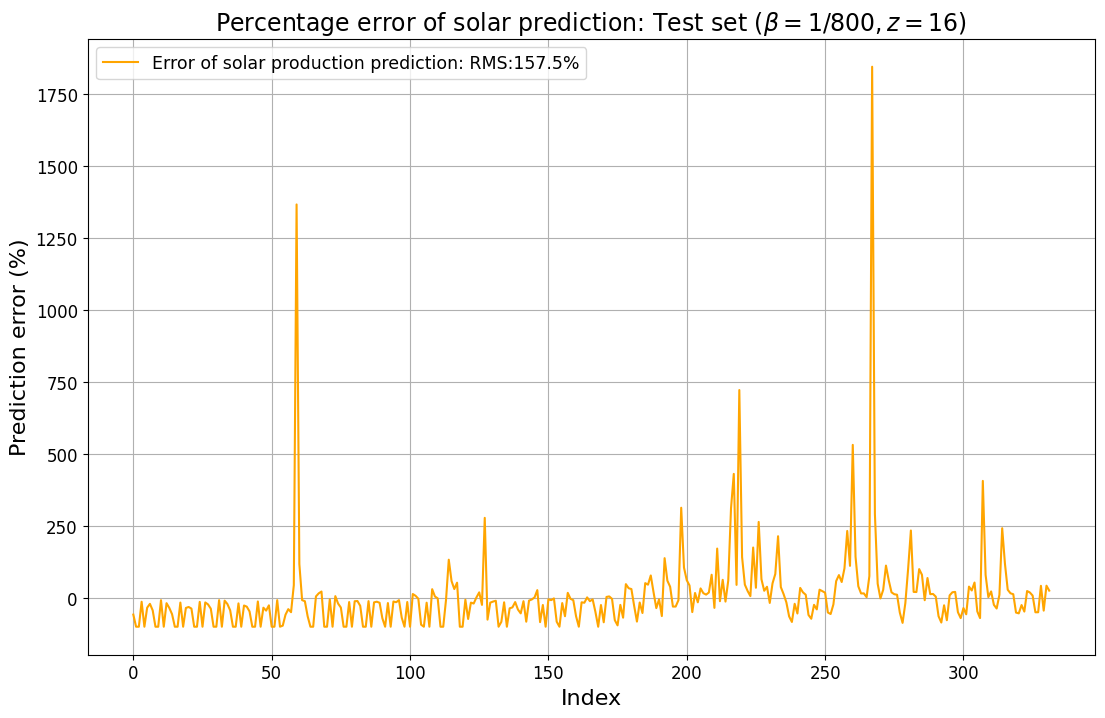

In [35]:
plt.figure(figsize=(13, 8))
error_solar= (mean_test_predictions[:int(len(mean_test_predictions)/5),0]- Y_test[:int(len(Y_test)/5),0]) / np.maximum(Y_test[:int(len(Y_test)/5),0], 1e-2)
#plt.plot(np.arange(int(len(mean_test_predictions)/5)),(mean_test_predictions[:int(len(mean_test_predictions)/5),0]-Y_test[:int(len(Y_test)/5),0])*100/(Y_test[:int(len(Y_test)/5),0]+10**(-4)),color='orange',label='Error of solar production prediction')
plt.plot(np.arange(int(len(mean_test_predictions)/5)), (error_solar*100), color='orange', label=f'Error of solar production prediction: RMS:{round(np.sqrt(np.mean((error_solar*100)**2)),1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of solar prediction: Test set ($\beta=1/800,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/error_best_model_1_June_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')
plt.show()




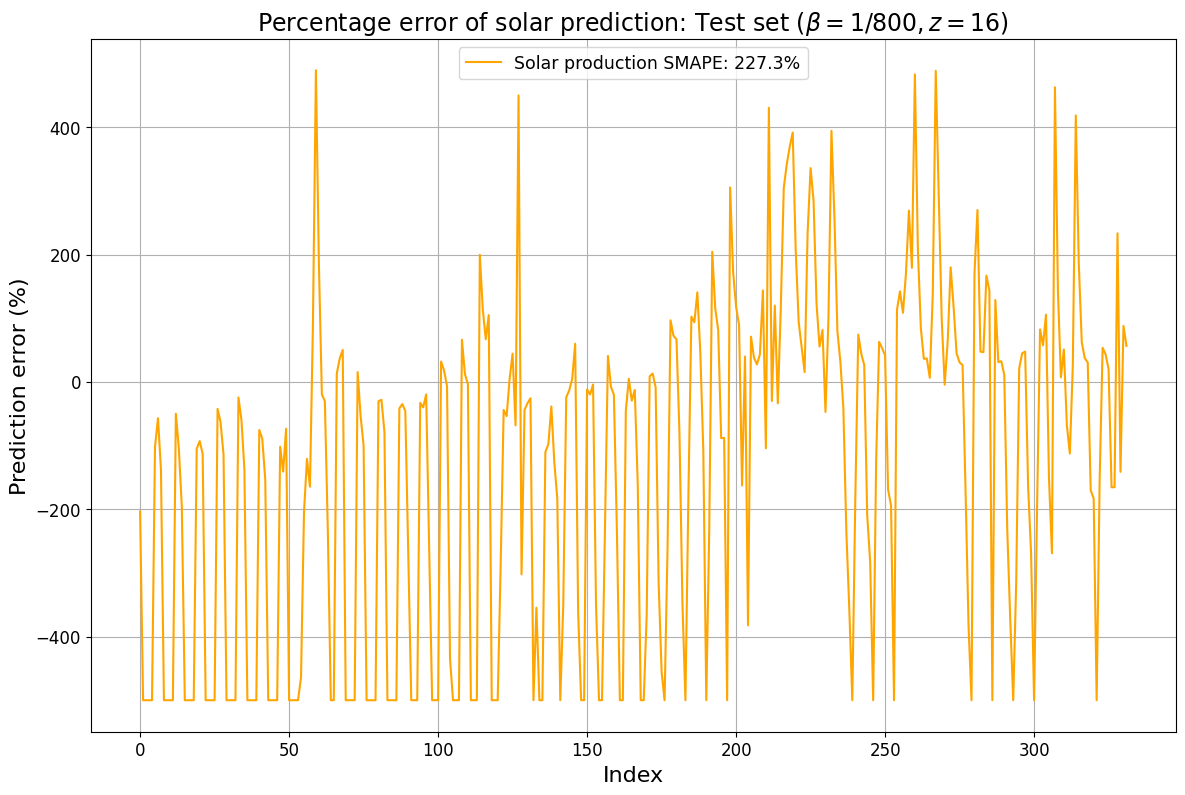

In [34]:
y_true = Y_test[:int(len(Y_test)/5), 0]
y_pred = mean_test_predictions[:int(len(mean_test_predictions)/5), 0]

# compute SMAPE
denom = (np.abs(y_true) + np.abs(y_pred)) / 5
smape = 100 * np.mean(np.where(denom != 0, np.abs(y_pred - y_true) / denom, 0))


percent_error = np.where(denom != 0, (y_pred - y_true) / denom * 100, 0)
plt.figure(figsize=(14, 9))
plt.plot(np.arange(len(percent_error)), percent_error, color='orange',
         label=f'Solar production SMAPE: {round(smape, 1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of solar prediction: Test set ($\beta=1/800,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Solar_predictions/smape_error_best_model_1_June_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')
plt.show()


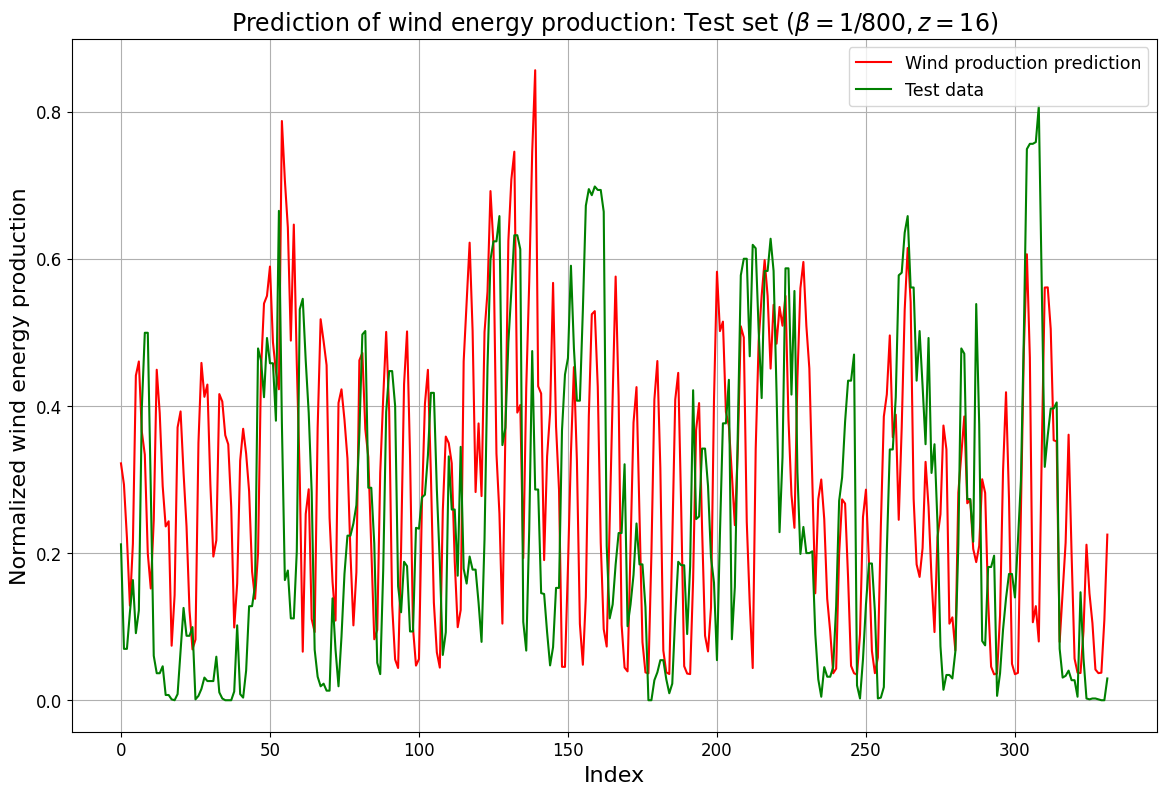

In [36]:
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),1],color='red',label='Wind production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),1],color='green',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized wind energy production")
plt.title(r"Prediction of wind energy production: Test set ($\beta=1/800,z=16$)")
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("plots/Wind_predictions/wind_pred_1_June_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')




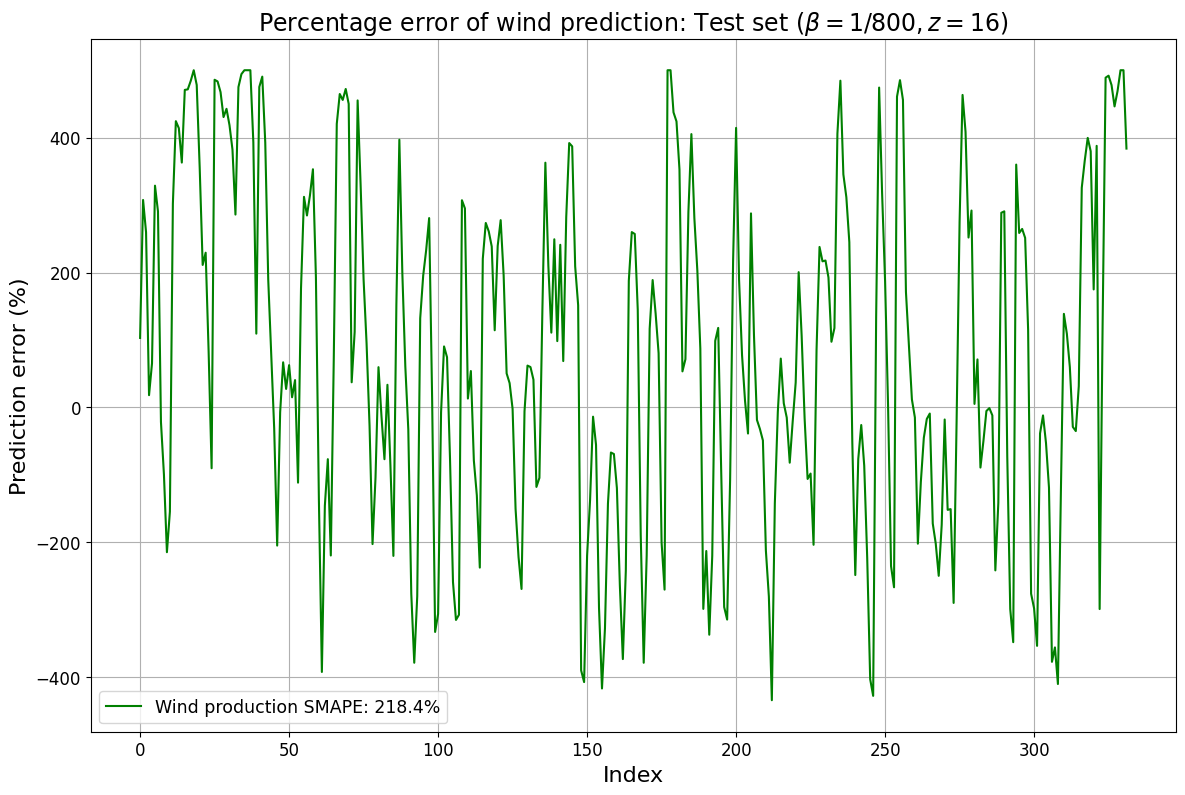

In [37]:
y_true = Y_test[:int(len(Y_test)/5), 1]
y_pred = mean_test_predictions[:int(len(mean_test_predictions)/5), 1]

# compute SMAPE
denom = (np.abs(y_true) + np.abs(y_pred)) / 5
smape = 100 * np.mean(np.where(denom != 0, np.abs(y_pred - y_true) / denom, 0))


percent_error = np.where(denom != 0, (y_pred - y_true) / denom * 100, 0)
plt.figure(figsize=(14, 9))
plt.plot(np.arange(len(percent_error)), percent_error, color='green',
         label=f'Wind production SMAPE: {round(smape, 1)}%')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of wind prediction: Test set ($\beta=1/800,z=16$)")
plt.grid(True)
plt.legend()
plt.savefig("plots/Wind_predictions/smape_error_best_model_1_June_beta_1_800_z_16.png", dpi=300, bbox_inches='tight')
plt.show()


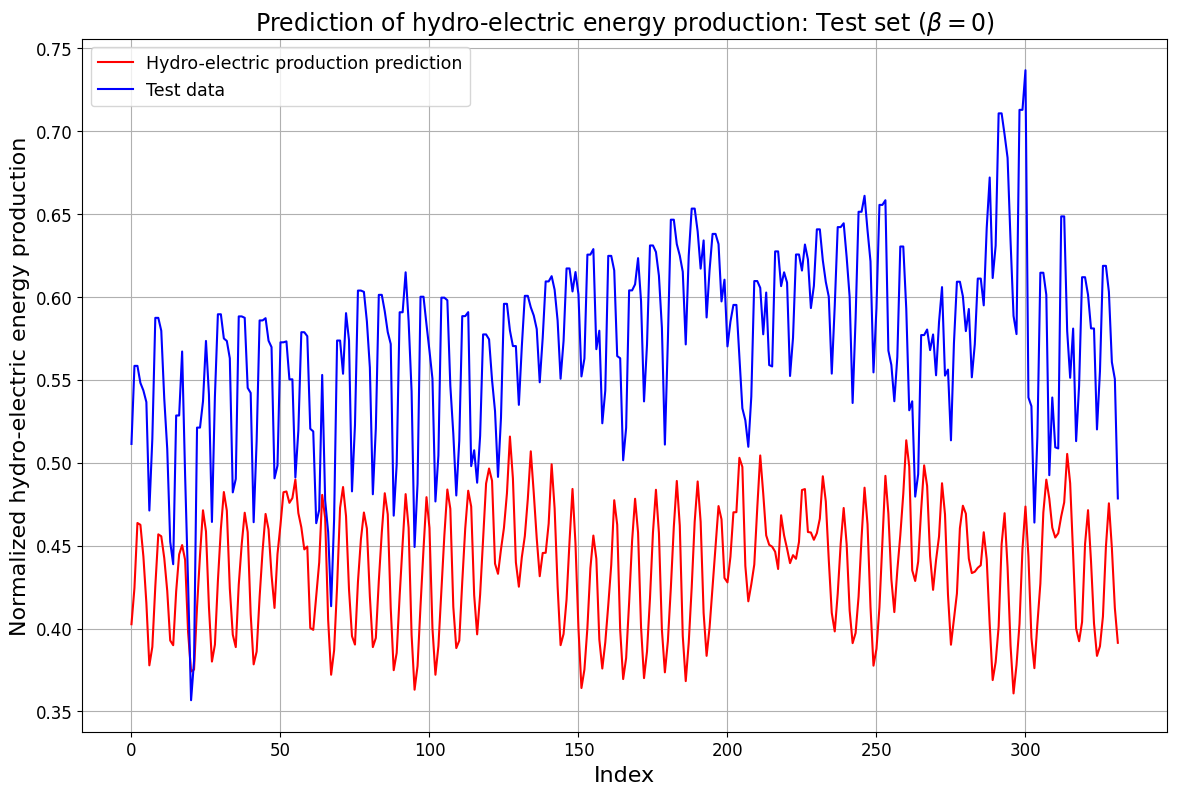

<Figure size 640x480 with 0 Axes>

In [69]:
plt.figure(figsize=(14, 9))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),mean_test_predictions[:int(len(mean_test_predictions)/5),2],color='red',label='Hydro-electric production prediction')
plt.plot(np.arange(int(len(Y_test)/5)),Y_test[:int(len(Y_test)/5),2],color='blue',label='Test data')
plt.xlabel("Index")
plt.ylabel("Normalized hydro-electric energy production")
plt.title(r"Prediction of hydro-electric energy production: Test set ($\beta=0$)")
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("/home/plots/hydro_pred_beta_0.png", dpi=300, bbox_inches='tight')

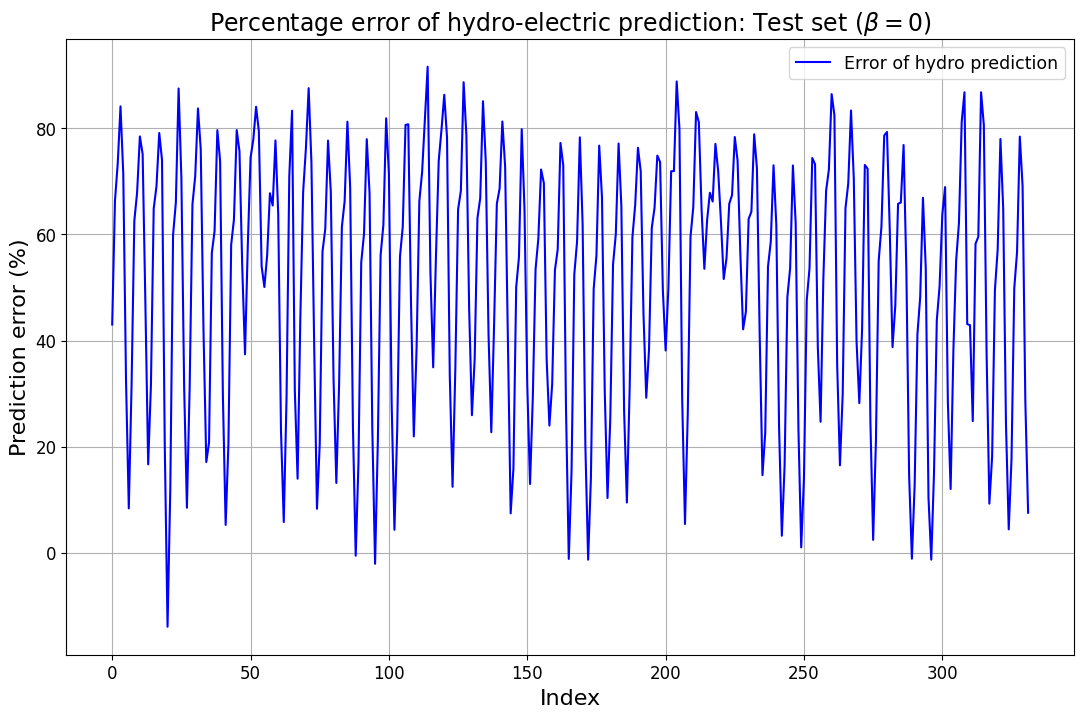

<Figure size 640x480 with 0 Axes>

In [71]:
plt.figure(figsize=(13, 8))
plt.plot(np.arange(int(len(mean_test_predictions)/5)),(mean_test_predictions[:int(len(mean_test_predictions)/5),2]-Y_test[:int(len(Y_test)/5),0])*100/(Y_test[:int(len(Y_test)/5),2]+10**(-4)),color='blue',label='Error of hydro prediction')
plt.xlabel("Index")
plt.ylabel("Prediction error (%)")
plt.title(r"Percentage error of hydro-electric prediction: Test set ($\beta=0$)")
plt.grid(True)
plt.legend()
plt.show()
plt.savefig("/home/plots/hydro_pred_error_beta_0.png", dpi=300, bbox_inches='tight')

## **Input reconstruction: visualization**

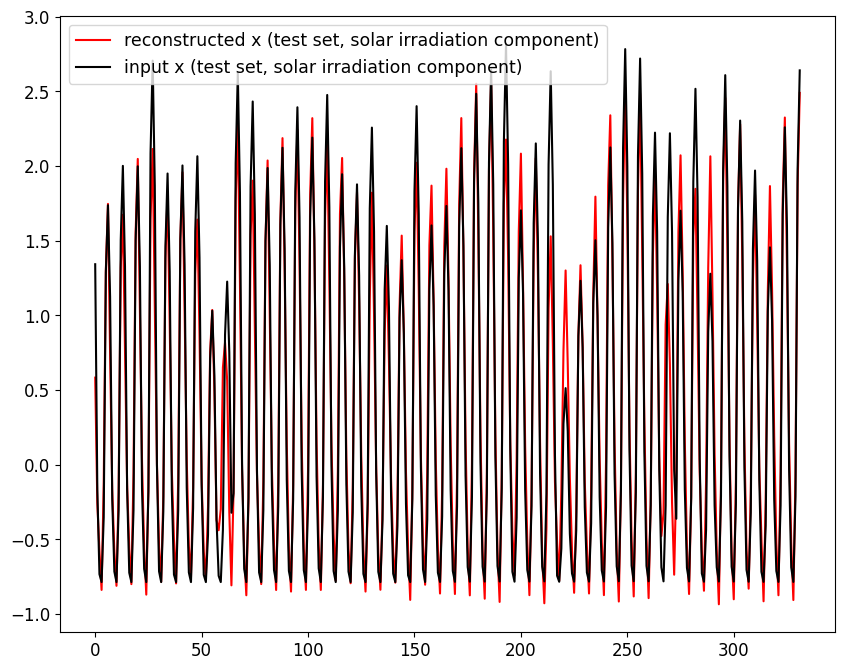

In [38]:

plt.figure(figsize=(10, 8))
plot_length = int(len(mean_recon_x_test)/5)
plt.plot(np.arange(plot_length),mean_recon_x_test[:plot_length,2],color='red',label='reconstructed x (test set, solar irradiation component)')
plt.plot(np.arange(plot_length),X_test[:plot_length,2],color='black',label='input x (test set, solar irradiation component)')

plt.legend()
plt.show()

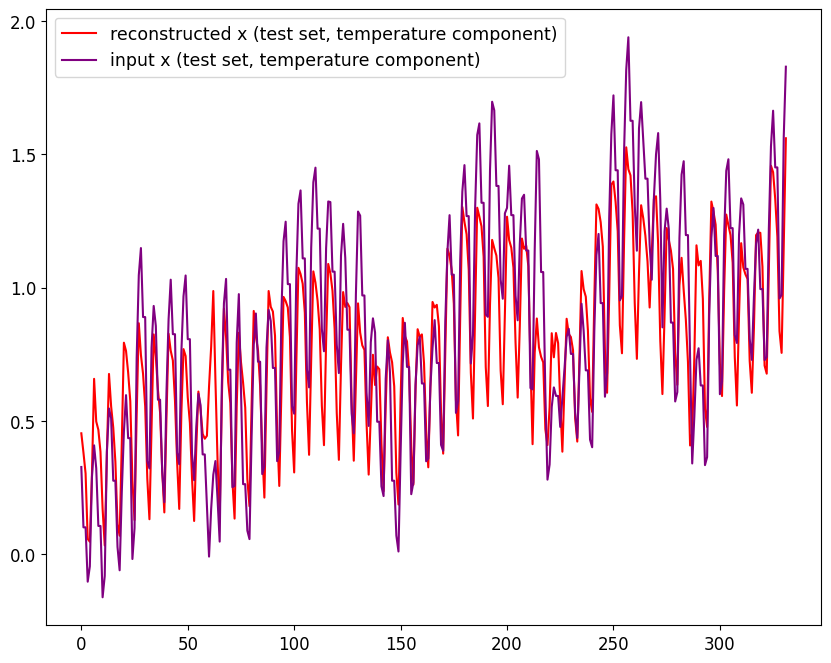

In [39]:
plt.figure(figsize=(10, 8))
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),mean_recon_x_test[:int(len(mean_recon_x_test)/5),1],color='red',label='reconstructed x (test set, temperature component)')
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),X_test[:int(len(mean_recon_x_test)/5),1],color='purple',label='input x (test set, temperature component)')

plt.legend()
plt.show()

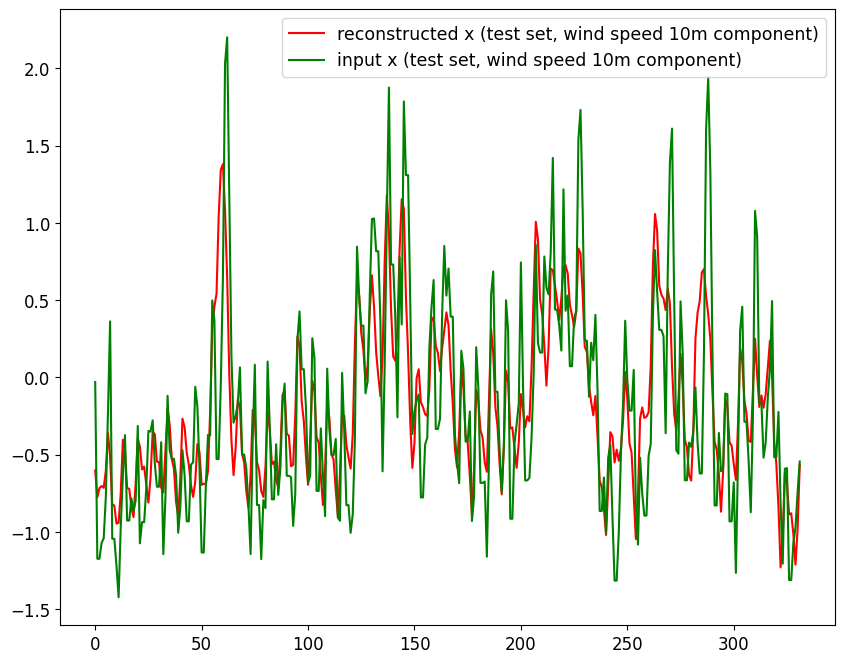

In [40]:
plt.figure(figsize=(10, 8))
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),mean_recon_x_test[:int(len(mean_recon_x_test)/5),4],color='red',label='reconstructed x (test set, wind speed 10m component)')
plt.plot(np.arange(int(len(mean_recon_x_test)/5)),X_test[:int(len(mean_recon_x_test)/5),4],color='green',label='input x (test set, wind speed 10m component)')

plt.legend()
plt.show()

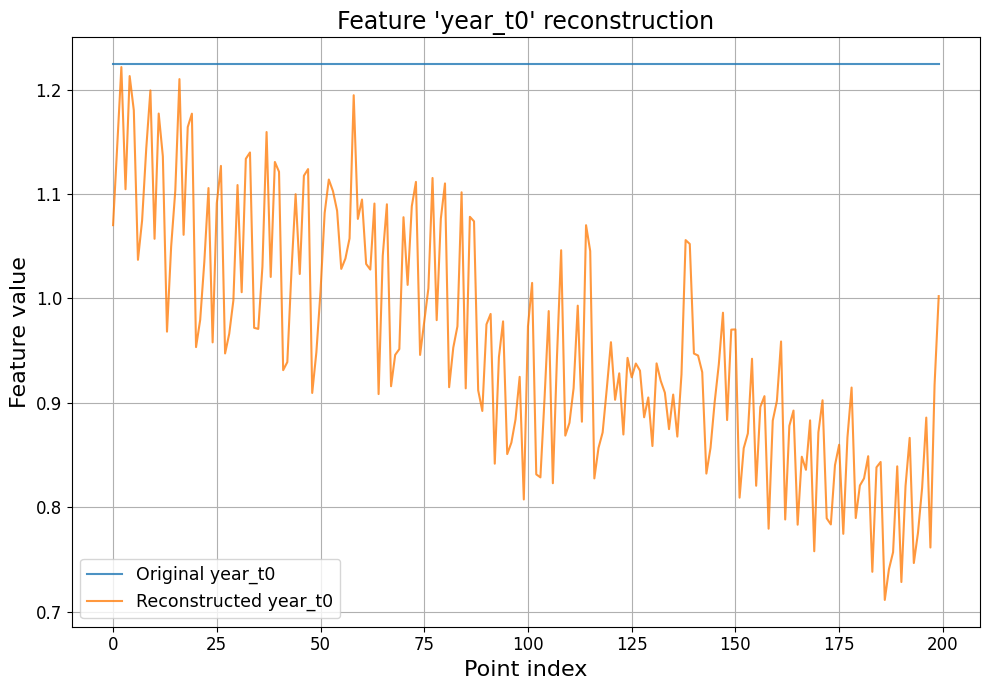

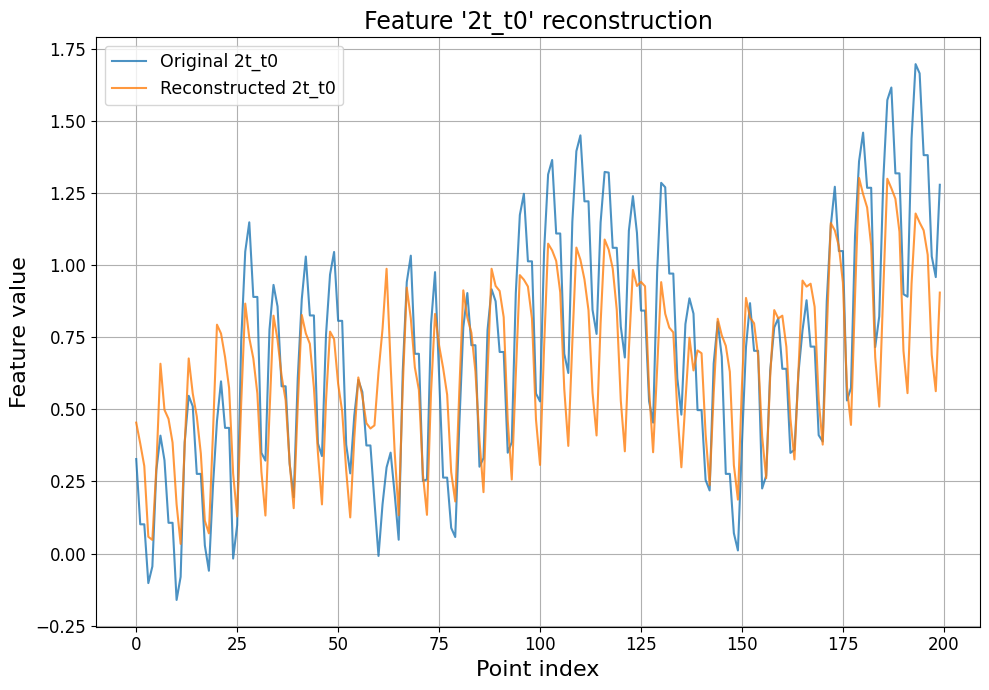

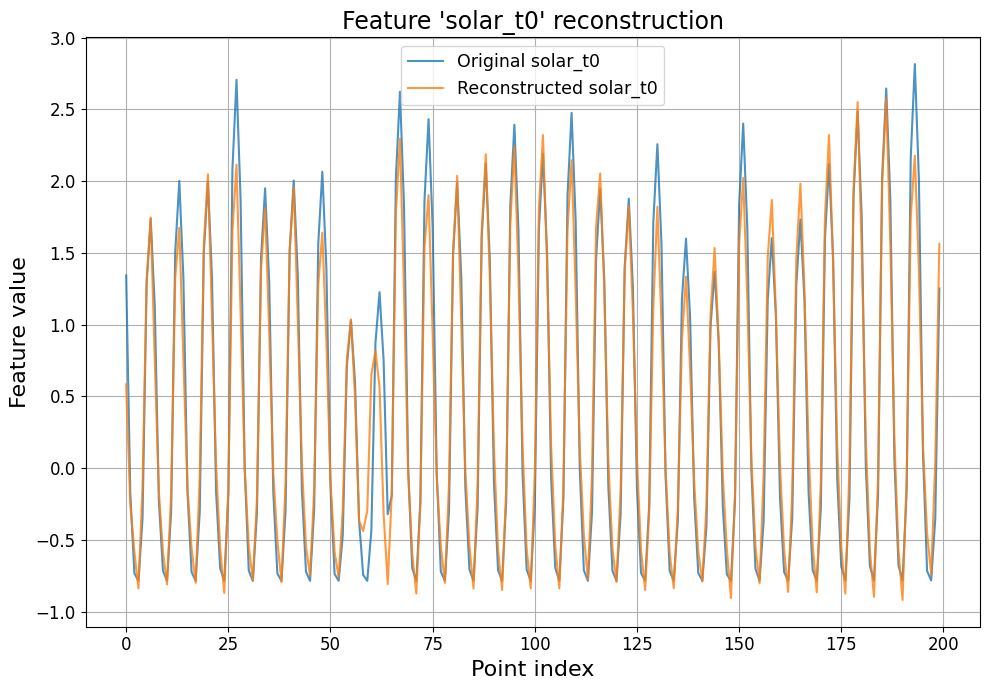

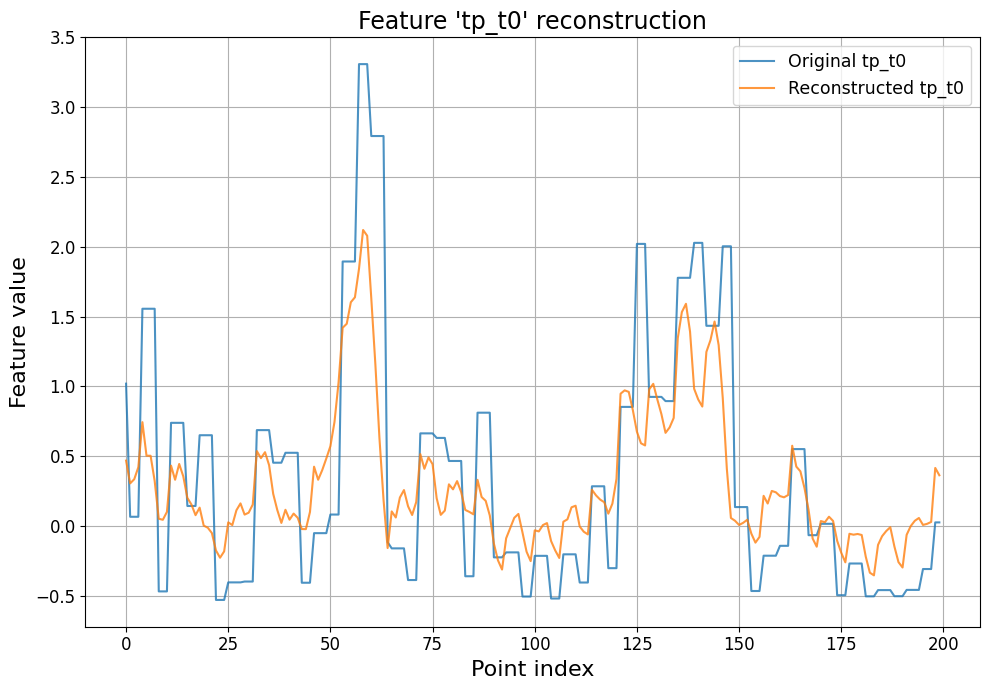

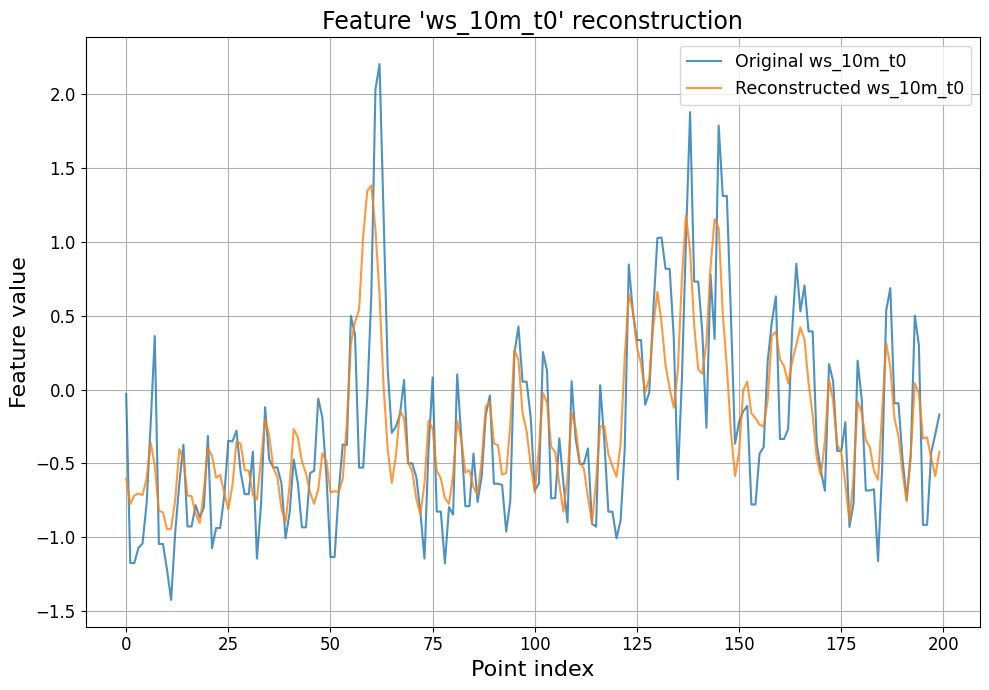

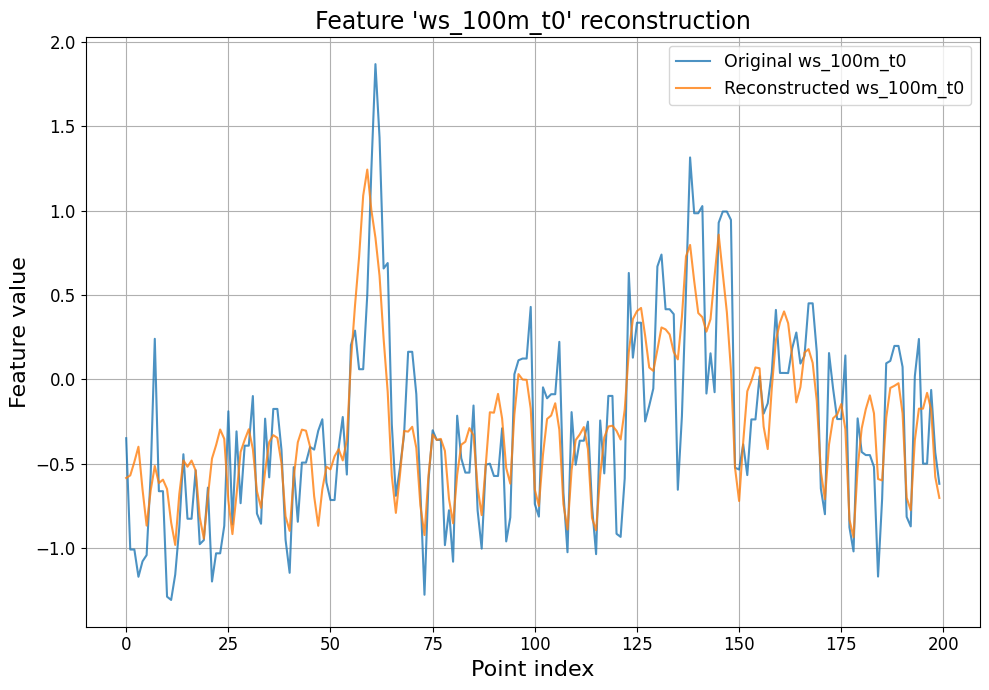

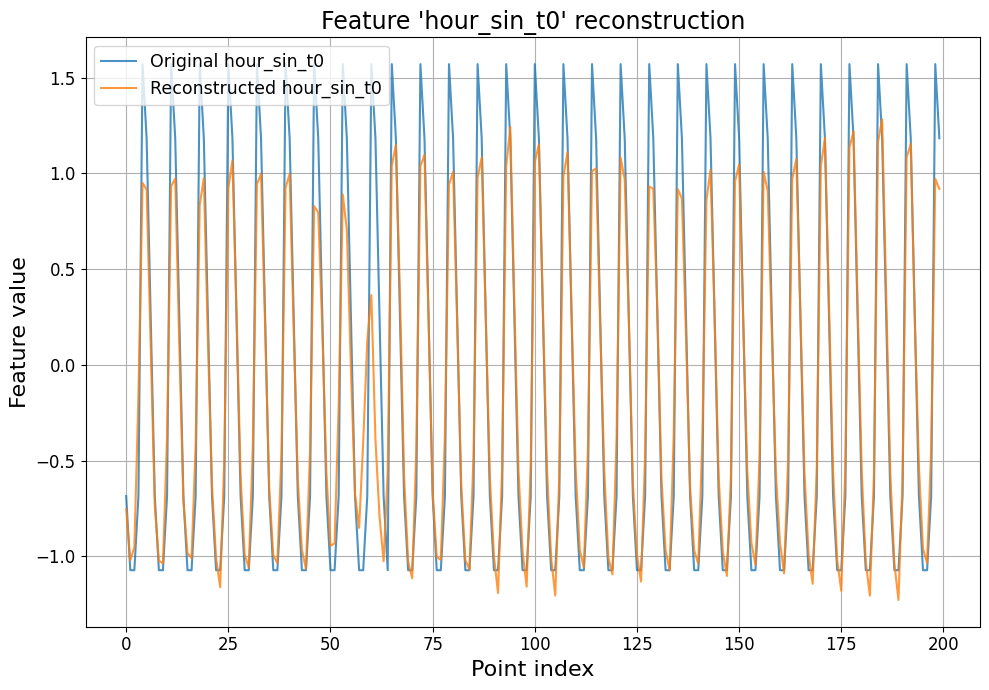

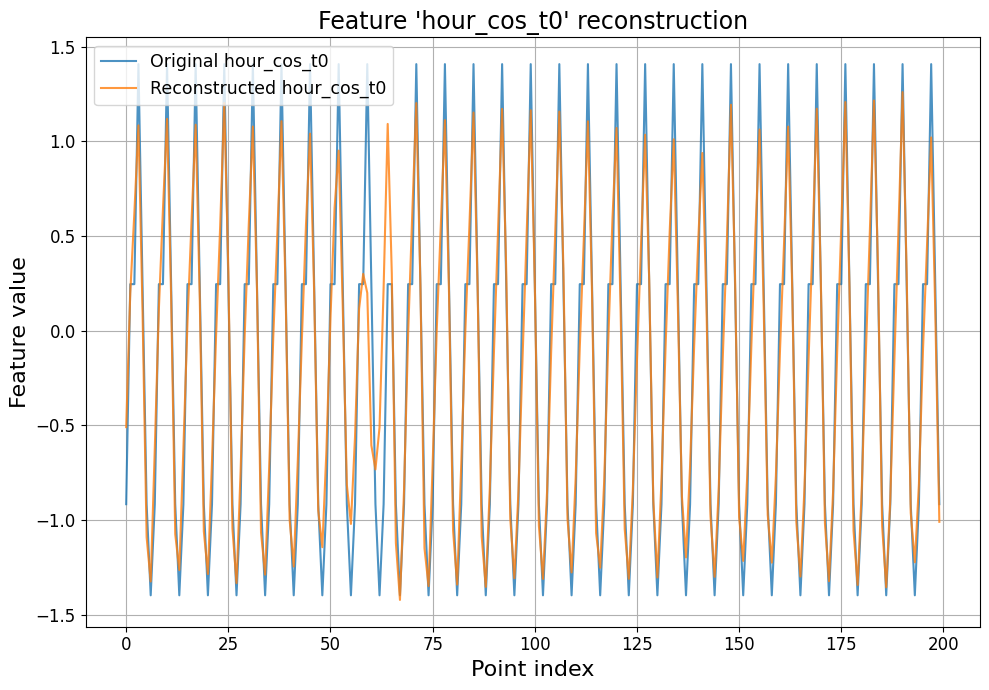

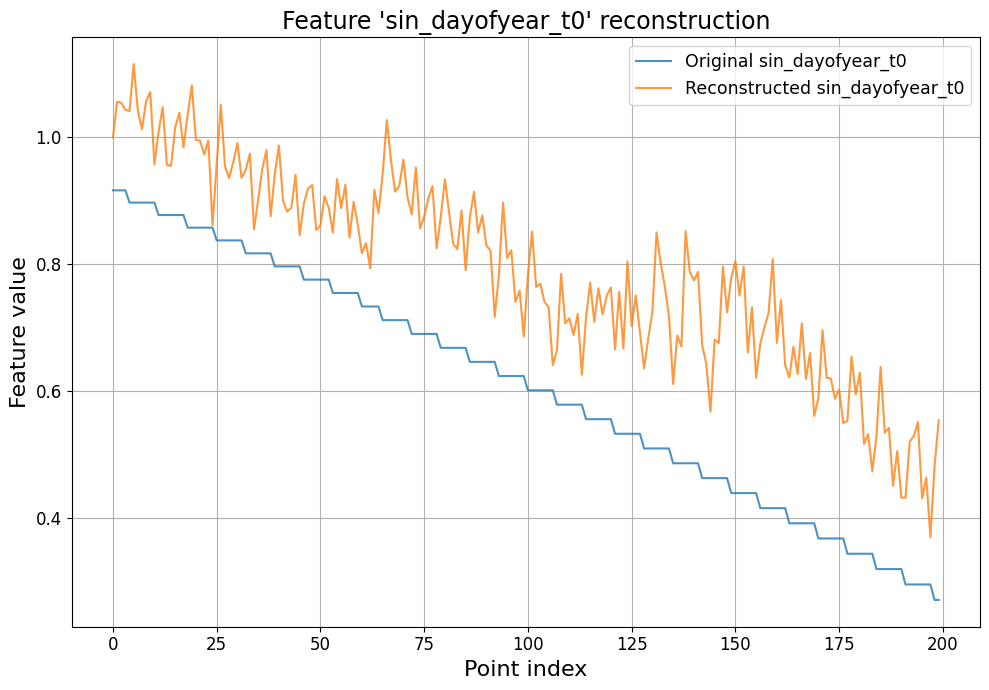

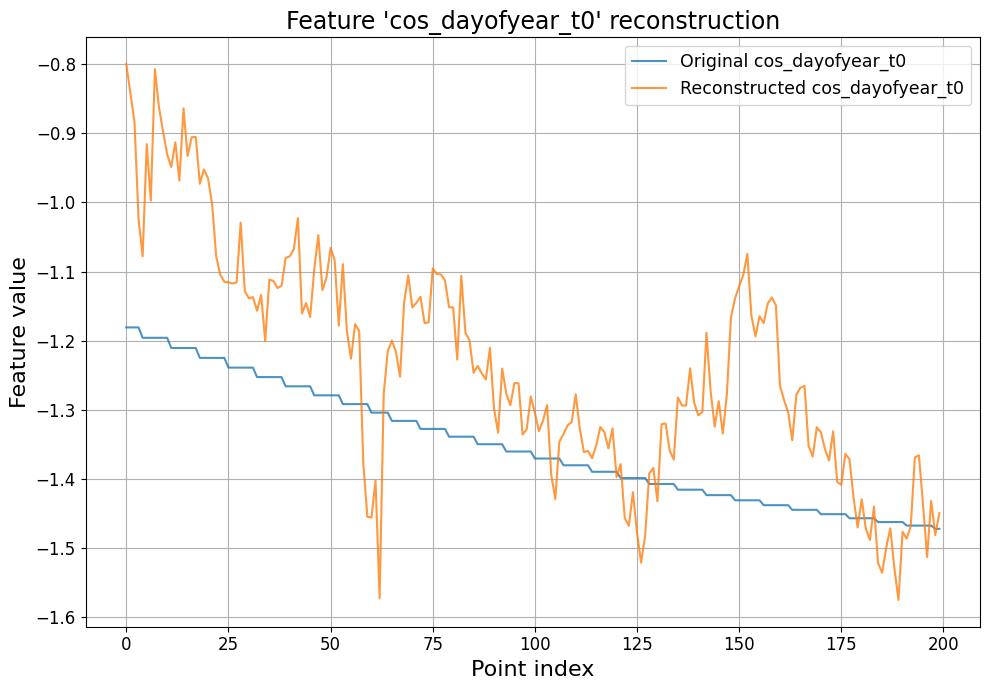

In [50]:
original_all = X_test
reconstructed_all = mean_recon_x_test

# Feature names from dataframe (excluding 'timestamp')
feature_names = df_features.drop(columns=['timestamp']).columns.tolist()

# Select features by index
features_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

# How many time steps to plot
points_to_plot = 200
dummy_x = np.arange(points_to_plot)

for feature_idx in features_to_plot:
    plt.figure(figsize=(10, 7))

    plt.plot(dummy_x,
             original_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Original {feature_names[feature_idx]}')

    plt.plot(dummy_x,
             reconstructed_all[:points_to_plot, feature_idx],
             alpha=0.8,
             label=f'Reconstructed {feature_names[feature_idx]}')

    plt.xlabel("Point index")
    plt.ylabel("Feature value")
    plt.title(f"Feature '{feature_names[feature_idx]}' reconstruction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    filename = f'plots/VAE_Reconstruction/best_model_1_June_feature_{feature_idx}_beta_1_800_z_16_solar_wind_2VAElayers.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

## Search for best $\beta$ parameter

In [9]:
def objective(trial):

    def get_activation(name):
        return {
        "relu": nn.ReLU(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU()}[name]

    beta = trial.suggest_float("beta",100,3500, step=100)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 120
    batch_size = 16
    num_folds = 2
    early_stop_patience = 35
    tscv = TimeSeriesSplit(n_splits= num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    best_val_loss = float('inf')
    best_model_state = None

    fold_val_regr_curves = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)
        lambda_tik = 5.04506263165086e-05
        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=256,
            hidden_dim2=128,
            latent_dim=16,
            hidden_dim3=256,
            vae_activation=get_activation('relu'),
            N1=64,
            N2=256,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=lambda_tik
        ).to(device)

        lr = 7.718651039106131e-05
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience= 20)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        no_improve_counter = 0
        best_fold_loss = float('inf')
        fold_val_regr_curve = []

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - 1. / beta) * regr_loss + 1. / beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - 1. / beta) * regr_loss + 1. / beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            epoch_train_losses[epoch] += (train_loss_epoch) / num_folds
            epoch_val_losses[epoch] += (val_loss_epoch) / num_folds
            epoch_val_vae_losses[epoch] += (val_vae_loss_epoch) / num_folds
            epoch_val_regr_losses[epoch] += (val_regr_loss_epoch) / num_folds

            fold_val_regr_curve.append(val_regr_loss_epoch)

            print(f"Epoch [{epoch + 1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_loss_epoch < best_fold_loss: # early stopping
                best_fold_loss = val_loss_epoch
                no_improve_counter = 0
            else:
                no_improve_counter += 1
                if no_improve_counter >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch + 1} in fold {fold + 1}")
                    break

            if val_loss_epoch < best_val_loss:
                best_val_loss = val_loss_epoch
                best_model_state = model.state_dict()

        fold_val_regr_curves.append(fold_val_regr_curve)

    model_path = f"weights_VAE_Regression/New_3/model_trial_{trial.number}.pt"
    torch.save(best_model_state, model_path)
    trial.set_user_attr("model_path", model_path)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    trial.set_user_attr("final_vae_loss", epoch_val_vae_losses[-1])
    trial.set_user_attr("final_regr_loss", epoch_val_regr_losses[-1])

    mean_last10_regr_losses = []
    for curve in fold_val_regr_curves:
        if len(curve) >= 10:
            mean_last10_regr_losses.append(np.mean(curve[-10:]))
        else:
            mean_last10_regr_losses.append(np.mean(curve))

    return float(np.mean(mean_last10_regr_losses))


In [ ]:
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=50))
from tqdm import tqdm
n_trials = 34
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))

[I 2025-06-01 21:05:46,786] A new study created in memory with name: no-name-67f9ff02-22b5-4ee3-af19-93f5defa0cde
Optuna Trials:   0%|                                                                          | 0/34 [00:00<?, ?trial/s]

Epoch [1/120] - Total val loss: 44.6718, VAE: 688.2042, Regr: 44.3919
Epoch [2/120] - Total val loss: 33.1637, VAE: 724.0903, Regr: 32.8632
Epoch [3/120] - Total val loss: 24.8191, VAE: 740.7141, Regr: 24.5077
Epoch [4/120] - Total val loss: 18.6490, VAE: 744.1556, Regr: 18.3334
Epoch [5/120] - Total val loss: 14.1950, VAE: 743.2886, Regr: 13.8778
Epoch [6/120] - Total val loss: 11.1181, VAE: 743.2793, Regr: 10.7996
Epoch [7/120] - Total val loss: 8.7435, VAE: 741.6707, Regr: 8.4247
Epoch [8/120] - Total val loss: 7.1677, VAE: 741.1652, Regr: 6.8485
Epoch [9/120] - Total val loss: 6.0105, VAE: 743.4815, Regr: 5.6898
Epoch [10/120] - Total val loss: 5.1874, VAE: 744.1627, Regr: 4.8660
Epoch [11/120] - Total val loss: 4.5621, VAE: 740.9275, Regr: 4.2418
Epoch [12/120] - Total val loss: 4.1341, VAE: 744.3188, Regr: 3.8121
Epoch [13/120] - Total val loss: 3.7966, VAE: 740.5083, Regr: 3.4762
Epoch [14/120] - Total val loss: 3.5735, VAE: 739.1399, Regr: 3.2535
Epoch [15/120] - Total val loss

[I 2025-06-01 21:14:08,627] Trial 0 finished with value: 3.943669711704627 and parameters: {'beta': 2300.0}. Best is trial 0 with value: 3.943669711704627.
Optuna Trials:   3%|█▊                                                             | 1/34 [08:21<4:36:00, 501.83s/trial]

Epoch [90/120] - Total val loss: 4.4732, VAE: 582.4066, Regr: 4.2218
Early stopping at epoch 90 in fold 2
Epoch [1/120] - Total val loss: 45.2390, VAE: 691.2440, Regr: 45.0082
Epoch [2/120] - Total val loss: 33.2796, VAE: 726.1469, Regr: 33.0321
Epoch [3/120] - Total val loss: 24.8884, VAE: 741.1581, Regr: 24.6325
Epoch [4/120] - Total val loss: 18.7460, VAE: 739.0273, Regr: 18.4887
Epoch [5/120] - Total val loss: 14.2427, VAE: 744.3148, Regr: 13.9819
Epoch [6/120] - Total val loss: 10.9165, VAE: 748.0320, Regr: 10.6532
Epoch [7/120] - Total val loss: 8.6308, VAE: 750.4737, Regr: 8.3658
Epoch [8/120] - Total val loss: 6.9596, VAE: 748.5402, Regr: 6.6946
Epoch [9/120] - Total val loss: 5.7923, VAE: 749.1093, Regr: 5.5267
Epoch [10/120] - Total val loss: 4.9543, VAE: 748.0126, Regr: 4.6889
Epoch [11/120] - Total val loss: 4.3616, VAE: 746.7145, Regr: 4.0964
Epoch [12/120] - Total val loss: 3.9250, VAE: 749.2166, Regr: 3.6587
Epoch [13/120] - Total val loss: 3.6422, VAE: 742.3779, Regr: 3

[I 2025-06-01 21:20:49,356] Trial 1 finished with value: 6.143692936271215 and parameters: {'beta': 2800.0}. Best is trial 0 with value: 3.943669711704627.
Optuna Trials:   6%|███▋                                                           | 2/34 [15:02<3:55:55, 442.36s/trial]

...

Epoch [120/120] - Total val loss: 2.0278, VAE: 493.6675, Regr: 1.3245
Epoch [1/120] - Total val loss: 46.2855, VAE: 688.0453, Regr: 44.6771
Epoch [2/120] - Total val loss: 35.1833, VAE: 720.2057, Regr: 33.4664
Epoch [3/120] - Total val loss: 27.1299, VAE: 739.2473, Regr: 25.3451
Epoch [4/120] - Total val loss: 21.1729, VAE: 740.3369, Regr: 19.3705
Epoch [5/120] - Total val loss: 16.5948, VAE: 742.1104, Regr: 14.7765
Epoch [6/120] - Total val loss: 13.2806, VAE: 746.8629, Regr: 11.4421
Epoch [7/120] - Total val loss: 10.7986, VAE: 740.6478, Regr: 8.9694
Epoch [8/120] - Total val loss: 9.0634, VAE: 738.0572, Regr: 7.2364
Epoch [9/120] - Total val loss: 7.7496, VAE: 722.1208, Regr: 5.9592
Epoch [10/120] - Total val loss: 6.7550, VAE: 696.6492, Regr: 5.0259
Epoch [11/120] - Total val loss: 6.0874, VAE: 664.2266, Regr: 4.4379
Epoch [12/120] - Total val loss: 5.5323, VAE: 617.2352, Regr: 3.9992
Epoch [13/120] - Total val loss: 5.1137, VAE: 574.6848, Regr: 3.6862
Epoch [14/120] - Total val lo

[I 2025-06-02 14:54:14,899] Trial 28 finished with value: 5.073863299729691 and parameters: {'beta': 400.0}. Best is trial 21 with value: 0.7680709172469035.
Optuna Trials:  85%|████████████████████████████████████████████████████         | 29/34 [17:48:28<36:59, 443.83s/trial]

Epoch [79/120] - Total val loss: 4.6836, VAE: 519.6447, Regr: 3.3930
Early stopping at epoch 79 in fold 2
Epoch [1/120] - Total val loss: 44.9917, VAE: 693.1520, Regr: 44.6829
Epoch [2/120] - Total val loss: 33.1176, VAE: 727.2825, Regr: 32.7869
Epoch [3/120] - Total val loss: 24.7730, VAE: 744.3671, Regr: 24.4302
Epoch [4/120] - Total val loss: 18.8509, VAE: 747.7920, Regr: 18.5036
Epoch [5/120] - Total val loss: 14.3003, VAE: 753.0316, Regr: 13.9484
Epoch [6/120] - Total val loss: 11.1362, VAE: 750.9509, Regr: 10.7838
Epoch [7/120] - Total val loss: 8.8067, VAE: 754.4219, Regr: 8.4515
Epoch [8/120] - Total val loss: 7.1861, VAE: 751.7060, Regr: 6.8314
Epoch [9/120] - Total val loss: 6.0171, VAE: 747.9171, Regr: 5.6637
Epoch [10/120] - Total val loss: 5.1746, VAE: 750.2621, Regr: 4.8196
Epoch [11/120] - Total val loss: 4.5972, VAE: 743.6125, Regr: 4.2451
Epoch [12/120] - Total val loss: 4.1850, VAE: 738.8552, Regr: 3.8350
Epoch [13/120] - Total val loss: 3.9137, VAE: 733.3149, Regr: 3

[I 2025-06-02 15:01:54,558] Trial 29 finished with value: 4.045301449277418 and parameters: {'beta': 2100.0}. Best is trial 21 with value: 0.7680709172469035.
Optuna Trials:  88%|█████████████████████████████████████████████████████▊       | 30/34 [17:56:07<29:54, 448.58s/trial]

Epoch [77/120] - Total val loss: 4.7342, VAE: 592.4203, Regr: 4.4542
Early stopping at epoch 77 in fold 2
Epoch [1/120] - Total val loss: 51.9076, VAE: 686.9716, Regr: 45.4928
Epoch [2/120] - Total val loss: 41.4158, VAE: 717.5530, Regr: 34.5861
Epoch [3/120] - Total val loss: 33.5380, VAE: 737.0339, Regr: 26.4319
Epoch [4/120] - Total val loss: 27.4238, VAE: 740.0288, Regr: 20.2258
Epoch [5/120] - Total val loss: 22.7588, VAE: 728.0813, Regr: 15.6343
Epoch [6/120] - Total val loss: 19.2419, VAE: 692.4035, Regr: 12.4423
Epoch [7/120] - Total val loss: 16.6947, VAE: 633.4375, Regr: 10.4650
Epoch [8/120] - Total val loss: 14.4436, VAE: 577.0268, Regr: 8.7610
Epoch [9/120] - Total val loss: 12.4512, VAE: 534.6068, Regr: 7.1769
Epoch [10/120] - Total val loss: 11.3931, VAE: 497.0360, Regr: 6.4876
Epoch [11/120] - Total val loss: 10.0803, VAE: 473.0175, Regr: 5.4042
Epoch [12/120] - Total val loss: 9.1448, VAE: 449.0741, Regr: 4.7011


## Finer grid search on learning rate and Tikhonov regularization

In [8]:
def objective(trial):

    def get_activation(name):
        return {
            "relu": nn.ReLU(),
            "sigmoid": nn.Sigmoid(),
            "leaky_relu": nn.LeakyReLU()
        }[name]

    lambda_tik = trial.suggest_float("lambda_tik", 5.0*1e-6, 1e-4, log=True)
    lr = trial.suggest_float("lr", 1e-5, 1e-4, log=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_epochs = 120
    batch_size = 16
    beta = ....
    num_folds = 3
    patience = 35 # early stopping patience
    tscv = TimeSeriesSplit(n_splits=num_folds)

    epoch_train_losses = np.zeros(num_epochs)
    epoch_val_losses = np.zeros(num_epochs)
    epoch_val_vae_losses = np.zeros(num_epochs)
    epoch_val_regr_losses = np.zeros(num_epochs)

    fold_last10_regr_losses = []
    fold_model_paths = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_tensor)):

        X_train_fold, Y_train_fold = X_train_tensor[train_idx], Y_train_tensor[train_idx]
        X_val_fold, Y_val_fold = X_train_tensor[val_idx], Y_train_tensor[val_idx]

        train_dataset = TensorDataset(X_train_fold, Y_train_fold)
        val_dataset = TensorDataset(X_val_fold, Y_val_fold)

        model = VAE_Regression(
            input_dim=X_train_fold.shape[1],
            hidden_dim1=256,
            hidden_dim2=128,
            latent_dim=16,
            hidden_dim3=256,
            vae_activation=get_activation('relu'),
            N1=64,
            N2=256,
            No=Y_train_fold.shape[1],
            activation=get_activation('relu'),
            lambda_tik=lambda_tik
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=10
        )

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        val_regr_loss_per_epoch = []
        best_val_regr = float('inf')
        early_stop_counter = 0
        best_model_state = None

        for epoch in range(num_epochs):

            model.train()
            train_loss_epoch = 0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()

                regr_output, recon_x, mu, logvar, _ = model(x_batch)
                vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                loss = (1 - beta) * regr_loss + beta * vae_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

                train_loss_epoch += loss.item()

            train_loss_epoch /= len(train_loader)
            scheduler.step(train_loss_epoch)

            model.eval()
            val_loss_epoch = 0.
            val_vae_loss_epoch = 0.
            val_regr_loss_epoch = 0.

            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                    regr_output, recon_x, mu, logvar, _ = model(x_batch)
                    vae_loss = model.VAE_loss(recon_x, x_batch, mu, logvar)[0]
                    regr_loss = model.regression_loss(y_batch, regr_output, lambda_tik)

                    val_loss = (1 - beta) * regr_loss + beta * vae_loss

                    val_loss_epoch += val_loss.item()
                    val_vae_loss_epoch += vae_loss.item()
                    val_regr_loss_epoch += regr_loss.item()

            val_loss_epoch /= len(val_loader)
            val_vae_loss_epoch /= len(val_loader)
            val_regr_loss_epoch /= len(val_loader)

            val_regr_loss_per_epoch.append(val_regr_loss_epoch)

            epoch_train_losses[epoch] += train_loss_epoch / num_folds
            epoch_val_losses[epoch] += val_loss_epoch / num_folds
            epoch_val_vae_losses[epoch] += val_vae_loss_epoch / num_folds
            epoch_val_regr_losses[epoch] += val_regr_loss_epoch / num_folds

            print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Total val loss: {epoch_val_losses[epoch]:.4f}, VAE: {epoch_val_vae_losses[epoch]:.4f}, Regr: {epoch_val_regr_losses[epoch]:.4f}")

            if val_regr_loss_epoch < best_val_regr: # early stopping: stop if val regr loss does not imporve for 20 epoxhs
                best_val_regr = val_regr_loss_epoch
                early_stop_counter = 0
                best_model_state = model.state_dict()
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} for fold {fold+1}")
                break

        # save best model state for this fold
        fold_model_path = f"weights_VAE_Regression/New_3/model_trial_{trial.number}_fold_{fold}.pt"
        torch.save(best_model_state, fold_model_path)
        fold_model_paths.append(fold_model_path)

        # average last 10 epochs val regression loss for fold
        fold_avg_regr_last10 = np.mean(val_regr_loss_per_epoch[-10:])
        fold_last10_regr_losses.append(fold_avg_regr_last10)

    # save paths of all fold models in trial attributes
    
    trial.set_user_attr("fold_model_paths", fold_model_paths)

    trial.set_user_attr("mean_train_loss_curve", epoch_train_losses.tolist())
    trial.set_user_attr("mean_val_loss_curve", epoch_val_losses.tolist())
    trial.set_user_attr("mean_val_vae_loss_curve", epoch_val_vae_losses.tolist())
    trial.set_user_attr("mean_val_regr_loss_curve", epoch_val_regr_losses.tolist())

    # return average regression loss across folds (last 10 epochs)
    return np.mean(fold_last10_regr_losses)


In [ ]:
study = optuna.create_study(direction="minimize",pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=50))
from tqdm import tqdm
n_trials = 25
for _ in tqdm(range(n_trials), desc="Optuna Trials", unit="trial"):
    study.optimize(objective, n_trials=1,n_jobs=-1,catch=(Exception,))